# Urban Change Detection with 3D Point Clouds

---

**Comparing LiDAR HD vs Satellite-Derived Point Clouds (CARS)**

| | |
|:--|:--|
| **Author** | [Florent Poux](https://learngeodata.eu) |
| **License** | MIT |
| **Python** | 3.10+ (Open3D compatible) |
| **Event** | CARS User Day - CNES |

---

## About This Workshop

**Special Thanks:**
- **CNES** for organizing the CARS User Day
- **[3D Geodata Academy](https://learngeodata.eu)** for supporting this educational material

This notebook was developed for the **CARS User Day** organized by CNES (Centre National d'Etudes Spatiales).

> *A l'occasion de la sortie de la version 1.0 de CARS, chaine 3D integree a la chaine image de la mission CO3D, le CNES organise une journee dediee aux utilisateurs avec une matinee de presentation et une apres-midi de travaux pratiques.*

**CARS** is an open-source 3D pipeline integrated into the CO3D mission image chain, enabling the generation of 3D point clouds from satellite stereo imagery.

---

## How to Use This Notebook

```
+---------------------------------------------------------------------+
|                     NOTEBOOK EXECUTION GUIDE                        |
+---------------------------------------------------------------------+
|  1. Run cells sequentially (Shift+Enter)                            |
|  2. Wait for each cell to complete before moving to the next        |
|  3. Visualizations will pop up - close them to continue             |
|  4. Adjust parameters in cells marked with "PARAMETERS"             |
|  5. For Google Colab: Run Step 0 first to install dependencies      |
+---------------------------------------------------------------------+
```

**Prerequisites:**
- Basic Python knowledge
- Understanding of 3D point clouds (helpful but not required)
- ~4GB RAM minimum (8GB+ recommended for large datasets)

**Data Requirements:**
- LiDAR HD reference data (LAS/LAZ format)
- CARS satellite-derived point cloud (LAS/LAZ format)
- Both datasets should cover the same geographic area

---

## What You Will Learn

```
LiDAR HD (Reference)          CARS Satellite (Target)
     |                              |
     +--------- COMPARE ------------+
                   |
         [Change Detection]
                   |
     +-------------+-------------+
     |             |             |
  Alignment    Demolished    New Construction
  Quality      Structures    Detection
```

This notebook walks through a complete urban change detection pipeline:

1. **Data Loading** - Multi-tile LAS/LAZ ingestion
2. **Pre-processing** - Cropping, voxel downsampling
3. **Alignment Assessment** - CRS verification & error quantification
4. **Signed Change Detection** - What appeared vs disappeared
5. **Attribute Transfer** - Classification propagation via k-NN
6. **Clustering** - DBSCAN-based object segmentation
7. **Feature Extraction** - PCA-based geometric descriptors
8. **Change Classification** - New vs removed structures
9. **3D Modeling** - Building mesh generation
10. **Export** - Production-ready outputs

---

## Acknowledgments & Resources

**Want to Learn More?**
- Book: [3D Data Science with Python](https://www.oreilly.com/library/view/3d-data-science/9781098161323/) (O'Reilly)
- Website: [learngeodata.eu](https://learngeodata.eu)

**Connect with Florent Poux:**
- [LinkedIn](https://www.linkedin.com/in/florent-poux/)
- [Medium](https://medium.com/@florentpoux)
- [YouTube](http://www.youtube.com/@FlorentPoux)

---

**License:** This work is licensed under the **MIT License**. You are free to use, modify, and distribute this code for any purpose.

---

## Step 0: Environment Setup

We import all required libraries. The pipeline uses:
- **NumPy** for vectorized computations
- **SciPy** for spatial indexing (cKDTree) and morphological operations
- **scikit-learn** for DBSCAN clustering
- **Open3D** for 3D visualization and mesh operations
- **Matplotlib** for 2D plots and colormaps
- **laspy** for LAS/LAZ point cloud I/O

```
    LIBRARY DEPENDENCIES
    +------------------+     +------------------+
    |     NumPy        |---->|  Core Arrays     |
    +------------------+     +------------------+
           |
           v
    +------------------+     +------------------+
    |     SciPy        |---->|  Spatial Index   |
    +------------------+     +------------------+
           |
           v
    +------------------+     +------------------+
    |    Open3D        |---->|  3D Viz & Mesh   |
    +------------------+     +------------------+
```

> **Florent's Note:** Open3D can be tricky to install on some systems. If you encounter issues, try `pip install open3d==0.17.0` for better compatibility. On Google Colab, the headless version works best for non-interactive visualizations.

In [1]:
# ============================================================================
# GOOGLE COLAB SETUP - Run this cell first if using Colab!
# ============================================================================
# Uncomment and run the following lines if you're on Google Colab:

# import sys
# IN_COLAB = 'google.colab' in sys.modules

# if IN_COLAB:
#     print("Running on Google Colab - Installing dependencies...")
#     !pip install -q laspy[lazrs] open3d scikit-learn scipy matplotlib numpy
#     
#     # Mount Google Drive to access data
#     from google.colab import drive
#     drive.mount('/content/drive')
#     
#     # Set visualization mode for Colab (no interactive windows)
#     COLAB_MODE = True
#     print("Dependencies installed! You may need to restart runtime.")
# else:
#     COLAB_MODE = False

# For local execution, just set:
COLAB_MODE = False  # Set to True if running on Colab without the above block

In [2]:
import numpy as np
import laspy
from pathlib import Path
from collections import Counter

from scipy.spatial import cKDTree, Delaunay
from scipy.ndimage import binary_fill_holes, distance_transform_edt
from scipy.stats import binned_statistic_2d

from sklearn.cluster import DBSCAN

import matplotlib.pyplot as plt

# Open3D import with fallback
try:
    import open3d as o3d
    OPEN3D_AVAILABLE = True
    print(f"Open3D version: {o3d.__version__}")
except ImportError:
    OPEN3D_AVAILABLE = False
    print("Warning: Open3D not available. 3D visualizations will be limited.")

# Set visualization mode based on environment
# 'local' = Open3D window, 'jupyter' = Plotly in notebook, 'matplotlib' = fallback
VIZ_MODE = 'local'  # Change to 'jupyter' for Colab or Jupyter environments

print("All libraries loaded successfully!")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Open3D version: 0.19.0
All libraries loaded successfully!


---

## Step 1: Visualization Functions

These helper functions handle 3D rendering with **coordinate centering** - critical for georeferenced data to avoid WebGL/Open3D precision issues with large coordinates (e.g., UTM values in millions).

> **Why Center Coordinates?**
> 
> GPU rendering uses 32-bit floats. When coordinates are large (like `X=456789.123`), 
> the decimal precision is lost, causing visual "wobble" or jittering. Subtracting 
> the centroid brings values close to zero where float precision is highest.

In [3]:

def visualize_point_cloud(points, colors=None, labels=None, mode='local',
                          title='Point Cloud', point_size=2, subsample=100000,
                          show_2d=True, show_3d=True):
    """Dual-mode visualization for local (Open3D) or Jupyter (Plotly) rendering with 2D/3D views"""

    # Subsample for performance if needed
    if len(points) > subsample:
        indices = np.random.choice(len(points), subsample, replace=False)
        points = points[indices]
        if colors is not None:
            colors = colors[indices]
        if labels is not None:
            labels = labels[indices]

    # Generate colors from labels if provided but colors not given
    if colors is None and labels is not None:
        unique_labels = np.unique(labels[labels >= 0])
        colormap = plt.colormaps['tab20'].resampled(len(unique_labels))
        colors = np.zeros((len(points), 3))
        for i, label in enumerate(unique_labels):
            mask = labels == label
            colors[mask] = colormap(i)[:3]
        # Gray for noise points
        colors[labels < 0] = [0.5, 0.5, 0.5]

    # Default blue if still no colors
    if colors is None:
        colors = np.tile([0.3, 0.5, 0.8], (len(points), 1))

    # Ensure colors are in [0, 1] range
    if colors.max() > 1.0:
        colors = colors / 255.0

    # Apply coordinate centering to avoid large coordinate wobble in 3D viz
    center = np.mean(points, axis=0)
    points_centered = points - center

    # 2D visualization (top-down view + side views) - use centered coords
    if show_2d:
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))

        # Top view (X-Y)
        axes[0, 0].scatter(points_centered[:, 0], points_centered[:, 1], c=colors, s=1, alpha=0.6)
        axes[0, 0].set_xlabel('X (m, centered)')
        axes[0, 0].set_ylabel('Y (m, centered)')
        axes[0, 0].set_title(f'{title} - Top View')
        axes[0, 0].axis('equal')
        axes[0, 0].grid(True, alpha=0.3)

        # Side view (X-Z)
        axes[0, 1].scatter(points_centered[:, 0], points_centered[:, 2], c=colors, s=1, alpha=0.6)
        axes[0, 1].set_xlabel('X (m, centered)')
        axes[0, 1].set_ylabel('Z (m, centered)')
        axes[0, 1].set_title(f'{title} - Side View (X-Z)')
        axes[0, 1].grid(True, alpha=0.3)

        # Side view (Y-Z)
        axes[1, 0].scatter(points_centered[:, 1], points_centered[:, 2], c=colors, s=1, alpha=0.6)
        axes[1, 0].set_xlabel('Y (m, centered)')
        axes[1, 0].set_ylabel('Z (m, centered)')
        axes[1, 0].set_title(f'{title} - Side View (Y-Z)')
        axes[1, 0].grid(True, alpha=0.3)

        # Height histogram (use original Z values)
        axes[1, 1].hist(points[:, 2], bins=50, alpha=0.7, edgecolor='black')
        axes[1, 1].set_xlabel('Z (m)')
        axes[1, 1].set_ylabel('Point Count')
        axes[1, 1].set_title('Height Distribution')
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # 3D visualization - use centered coordinates
    if show_3d:
        if mode == 'local':
            pcd = o3d.geometry.PointCloud()
            pcd.points = o3d.utility.Vector3dVector(points_centered)
            pcd.colors = o3d.utility.Vector3dVector(colors)
            o3d.visualization.draw_geometries([pcd], window_name=title,
                                             point_show_normal=False)

        elif mode == 'jupyter':
            pcd = o3d.geometry.PointCloud()
            pcd.points = o3d.utility.Vector3dVector(pts_centered*[1,1,10])
            pcd.colors = o3d.utility.Vector3dVector(colors)
            o3d.visualization.draw_plotly([pcd], window_name=title, width=1024, height=768)
            
        else:
            # Fallback matplotlib 3D (always available)
            fig = plt.figure(figsize=(12, 8))
            ax = fig.add_subplot(111, projection='3d')
            ax.scatter(points_centered[:, 0], points_centered[:, 1], points_centered[:, 2],
                      c=colors, s=0.5, alpha=0.6)
            ax.set_xlabel('X (m, centered)')
            ax.set_ylabel('Y (m, centered)')
            ax.set_zlabel('Z (m, centered)')
            ax.set_title(title)
            plt.tight_layout()
            plt.show()


def map_classifications(input_labels, label_dict=None):
    """Map input classification codes to standardized ASPRS-like categories"""
    
    # Default ASPRS LAS 1.4 classification mapping
    if label_dict is None:
        label_dict = {
            0: 0,   # Never classified / Unclassified
            1: 0,   # Unassigned
            2: 1,   # Ground
            3: 2,   # Low Vegetation
            4: 2,   # Medium Vegetation  
            5: 2,   # High Vegetation
            6: 3,   # Building
            7: 4,   # Low Point (noise)
            9: 5,   # Water
            17: 6,  # Bridge
            18: 4,  # High noise
        }
    
    mapped = np.zeros_like(input_labels, dtype=np.int32)
    for input_code, output_code in label_dict.items():
        mapped[input_labels == input_code] = output_code
    
    return mapped


def compute_bounding_box(points):
    """Calculate spatial extent and center of point cloud"""
    
    min_bound = np.min(points, axis=0)
    max_bound = np.max(points, axis=0)
    center = (min_bound + max_bound) / 2
    extent = max_bound - min_bound
    
    return {
        'min': min_bound,
        'max': max_bound,
        'center': center,
        'extent': extent,
        'volume': np.prod(extent)
    }

# Time to test step 0 - Let's create a tiny synthetic dataset and visualize it!
print("Testing Step 0: Visualization Setup")
synthetic_points = np.random.randn(1000, 3) * 10
synthetic_labels = np.random.randint(0, 5, 1000)
visualize_point_cloud(synthetic_points, labels=synthetic_labels, mode='local', 
                     title='Test Visualization', show_2d=False, show_3d=True)
print("✓ Visualization functions ready\n")

Testing Step 0: Visualization Setup
✓ Visualization functions ready



In [4]:
def viz_3d_centered(points, colors=None, title="Point Cloud", subsample=500000, mode='local'):
    """
    Reusable 3D visualization with coordinate centering for georeferenced data.
    Avoids WebGL/Open3D precision issues from large coordinates.
    """
    n = len(points)
    idx = np.random.choice(n, min(subsample, n), replace=False) if n > subsample else np.arange(n)
    pts = points[idx]
    center = pts.mean(axis=0)
    pts_centered = pts - center

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts_centered)
    if colors is not None:
        pcd.colors = o3d.utility.Vector3dVector(colors[idx] if len(colors) == n else colors)
    else:
        pcd.paint_uniform_color([0.5, 0.5, 0.8])
    if mode == 'local':
        o3d.visualization.draw_geometries([pcd], window_name=title)
    else:
        o3d.visualization.draw_plotly([pcd], window_name=title)


def visualize_signed_changes(ref_pts, target_pts, threshold=0.25, viz_sample=500000, mode='local'):
    """
    Signed change visualization: LiDAR as reference.
    - Grey: |diff| < threshold (no significant change)
    - Red: negative diff (disappeared/demolished)
    - Green: positive diff (new construction)
    """
    tree = cKDTree(target_pts)
    dists, idx = tree.query(ref_pts, k=1, workers=-1)
    z_diff = ref_pts[:, 2] - target_pts[idx, 2]  # positive = LiDAR higher = demolished

    # Color assignment
    colors = np.full((len(ref_pts), 3), 0.5)  # grey default
    colors[z_diff < -threshold] = [0.2, 0.8, 0.2]  # green = constructed (target higher)
    colors[z_diff > threshold] = [0.9, 0.2, 0.2]   # red = demolished (LiDAR higher)

    # Subsample and visualize
    n = len(ref_pts)
    idx_viz = np.random.choice(n, min(viz_sample, n), replace=False)
    pts, cols = ref_pts[idx_viz], colors[idx_viz]
    center = pts.mean(axis=0)

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts - center)
    pcd.colors = o3d.utility.Vector3dVector(cols)
    pcd.estimate_normals()
    if mode == 'local':
        o3d.visualization.draw_geometries([pcd], window_name="Signed Changes (Grey=stable, Red=Negative, Green=Positive)")
    else:
        o3d.visualization.draw_plotly([pcd], window_name="Signed Changes (Grey=stable, Red=Negative, Green=Positive)")

    print(f"   New Elements: {(z_diff > threshold).sum():,} | Old State: {(z_diff < -threshold).sum():,} | Stable: {(np.abs(z_diff) <= threshold).sum():,}")

def viz_segments_3d(points, labels, title="Segments", subsample=500000, mode='local'):
    """Visualize clustered segments with distinct colors (centered)."""
    n = len(points)
    idx = np.random.choice(n, min(subsample, n), replace=False) if n > subsample else np.arange(n)
    pts, lbls = points[idx], labels[idx]
    center = pts.mean(axis=0)
    pts_centered = pts - center

    # Colorize by label
    cmap = plt.colormaps['tab20']
    colors = np.full((len(pts), 3), 0.3)
    valid = lbls >= 0
    colors[valid] = cmap((lbls[valid] % 20) / 19.0)[:, :3]
    
    if mode == 'local':
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts_centered)
        pcd.colors = o3d.utility.Vector3dVector(colors)
        o3d.visualization.draw_geometries([pcd], window_name=title)
    else:
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts_centered*[1,1,10])
        pcd.colors = o3d.utility.Vector3dVector(colors)
        o3d.visualization.draw_plotly([pcd], window_name=title)


def viz_dual_3d_centered(pts1, colors1, pts2, colors2, title="Dual View", subsample=300000, mode='local'):
    """Visualize two point clouds side by side with shared centering."""
    if not OPEN3D_AVAILABLE:
        return
    idx1 = np.random.choice(len(pts1), min(subsample, len(pts1)), replace=False)
    idx2 = np.random.choice(len(pts2), min(subsample, len(pts2)), replace=False)
    all_pts = np.vstack([pts1[idx1], pts2[idx2]])
    center = all_pts.mean(axis=0)

    pcd1 = o3d.geometry.PointCloud()
    pcd1.points = o3d.utility.Vector3dVector(pts1[idx1] - center)
    pcd1.colors = o3d.utility.Vector3dVector(colors1[idx1] if len(colors1) == len(pts1) else np.tile(colors1, (len(idx1), 1)))

    pcd2 = o3d.geometry.PointCloud()
    pcd2.points = o3d.utility.Vector3dVector(pts2[idx2] - center)
    pcd2.colors = o3d.utility.Vector3dVector(colors2[idx2] if len(colors2) == len(pts2) else np.tile(colors2, (len(idx2), 1)))

    if mode == 'local':
        o3d.visualization.draw_geometries([pcd1, pcd2], window_name=title)
    else:
        o3d.visualization.draw_plotly([pcd1, pcd2], window_name=title)

def visualize_dual_point_clouds(pc1, pc2, name1='Reference', name2='Target',
                                color1=[0.2, 0.6, 0.9], color2=[0.9, 0.3, 0.2],
                                subsample=15000, point_size=2, mode='local'):
    """Visualize two point clouds in the same 3D viewer with coordinate centering"""

    # Subsample for performance
    if len(pc1) > subsample:
        idx1 = np.random.choice(len(pc1), subsample, replace=False)
        pc1_sub = pc1[idx1]
    else:
        pc1_sub = pc1

    if len(pc2) > subsample:
        idx2 = np.random.choice(len(pc2), subsample, replace=False)
        pc2_sub = pc2[idx2]
    else:
        pc2_sub = pc2

    # Compute global center to avoid large coordinate wobble in WebGL
    all_points = np.vstack([pc1_sub, pc2_sub])
    center = np.mean(all_points, axis=0)

    # Center the coordinates (critical for Plotly/WebGL stability)
    pc1_centered = pc1_sub - center
    pc2_centered = pc2_sub - center

    print(f"Coordinate offset applied: [{center[0]:.1f}, {center[1]:.1f}, {center[2]:.1f}]")
    pcd1 = o3d.geometry.PointCloud()
    pcd1.points = o3d.utility.Vector3dVector(pc1_centered)
    pcd1.colors = o3d.utility.Vector3dVector(np.tile(color1, (len(pc1_centered), 1)))
    pcd1.estimate_normals()

    pcd2 = o3d.geometry.PointCloud()
    pcd2.points = o3d.utility.Vector3dVector(pc2_centered)
    pcd2.colors = o3d.utility.Vector3dVector(np.tile(color2, (len(pc2_centered), 1)))
    pcd2.estimate_normals()
    
    if mode == 'local':
        # Open3D version
        o3d.visualization.draw_geometries([pcd1, pcd2], window_name=f'{name1} vs {name2}')
    else:
        o3d.visualization.draw_plotly([pcd1, pcd2], window_name=f'{name1} vs {name2}')



def viz_multimodal(geometries, title="3D View", center=None):
    """Visualize mesh + point cloud together."""
    vis = o3d.visualization.Visualizer()
    vis.create_window(window_name=title)

    for geom in geometries:
        if isinstance(geom, o3d.geometry.TriangleMesh):
            g = o3d.geometry.TriangleMesh(geom)
        elif isinstance(geom, o3d.geometry.PointCloud):
            g = o3d.geometry.PointCloud(geom)
        else:
            g = geom
        if center is not None:
            g.translate(-center)
        vis.add_geometry(g)

    opt = vis.get_render_option()
    opt.mesh_show_back_face = True
    opt.light_on = True
    opt.point_size = 2.0
    vis.run()
    vis.destroy_window()

---

## Step 2: Data Loading

We load point clouds from **LAS/LAZ** files. The pipeline supports:
- Single file loading
- Multi-tile folder merging
- Classification extraction (ASPRS codes)
- RGB color handling (8-bit, 12-bit, 16-bit auto-detection)

```
   LAS File Structure
   +-----------------+
   | Header          |  <- CRS, scale, offset
   +-----------------+
   | Point Records   |  <- X, Y, Z, Classification, RGB
   +-----------------+
```

In [5]:
def load_point_cloud(filepath, load_classification=True, load_colors=True):
    """Load LAS/LAZ file and extract coordinates with optional classifications and RGB colors."""
    las = laspy.read(filepath)
    points = np.vstack([las.x, las.y, las.z]).T

    classifications = None
    if load_classification and 'classification' in las.point_format.dimension_names:
        classifications = np.array(las.classification)

    colors = None
    if load_colors and hasattr(las, 'red'):
        r = np.array(las.red, dtype=np.float32)
        g = np.array(las.green, dtype=np.float32)
        b = np.array(las.blue, dtype=np.float32)
        max_val = max(r.max(), g.max(), b.max(), 1.0)
        divisor = 65535.0 if max_val > 4095 else (4095.0 if max_val > 255 else 255.0)
        colors = np.clip(np.column_stack((r, g, b)) / divisor, 0.0, 1.0)

    return points, classifications, colors


def load_multi_tile_folder(folder_path, load_classification=True, load_colors=True):
    """Load and merge all LAZ tiles from a folder."""
    folder = Path(folder_path)
    laz_files = sorted(set(list(folder.glob('*.laz')) + list(folder.glob('*.copc.laz'))), key=lambda x: x.name)
    if not laz_files:
        laz_files = sorted(folder.glob('*.las'))

    print(f"Found {len(laz_files)} tiles in {folder_path}")

    all_points, all_classifications, all_colors = [], [], []
    for laz_file in laz_files:
        points, classifications, colors = load_point_cloud(str(laz_file), load_classification, load_colors)
        all_points.append(points)
        if classifications is not None:
            all_classifications.append(classifications)
        if colors is not None:
            all_colors.append(colors)
        print(f"  Loaded {laz_file.name}: {len(points):,} points")

    merged_points = np.vstack(all_points)
    merged_classifications = np.hstack(all_classifications) if all_classifications else None
    merged_colors = np.vstack(all_colors) if all_colors else None

    print(f"Total merged: {len(merged_points):,} points\n")
    return merged_points, merged_classifications, merged_colors

def compute_bounding_box(points):
    """Calculate spatial extent and center of point cloud."""
    min_bound = np.min(points, axis=0)
    max_bound = np.max(points, axis=0)
    return {'min': min_bound, 'max': max_bound, 'center': (min_bound + max_bound) / 2, 'extent': max_bound - min_bound}

In [6]:
# Load Reference LiDAR HD
print("Loading Reference LiDAR HD...")
ref_points_raw, ref_classes_raw, ref_colors_raw = load_multi_tile_folder(
    'ROI_INDUS/LIDAR_HD/', load_classification=True, load_colors=True
)

# Load Target CARS (Satellite Reconstruction)
print("Loading Target CARS...")
target_points_raw, target_classes_raw, target_colors_raw = load_multi_tile_folder(
    'ROI_INDUS/CARS/', load_classification=True, load_colors=True
)

print(f"\nReference (LiDAR HD): {len(ref_points_raw):,} points")
print(f"Target (CARS):        {len(target_points_raw):,} points")

Loading Reference LiDAR HD...
Found 4 tiles in ROI_INDUS/LIDAR_HD/
  Loaded LHD_FXX_0571_6274_PTS_LAMB93_IGN69.copc.laz: 23,770,487 points
  Loaded LHD_FXX_0571_6275_PTS_LAMB93_IGN69.copc.laz: 23,452,586 points
  Loaded LHD_FXX_0572_6274_PTS_LAMB93_IGN69.copc.laz: 24,207,375 points
  Loaded LHD_FXX_0572_6275_PTS_LAMB93_IGN69.copc.laz: 24,095,873 points
Total merged: 95,526,321 points

Loading Target CARS...
Found 2 tiles in ROI_INDUS/CARS/
  Loaded ROI_INDUS_PC_12_EPSG2154.laz: 2,123,145 points
  Loaded ROI_INDUS_PC_13_EPSG2154.laz: 2,015,274 points
Total merged: 4,138,419 points


Reference (LiDAR HD): 95,526,321 points
Target (CARS):        4,138,419 points


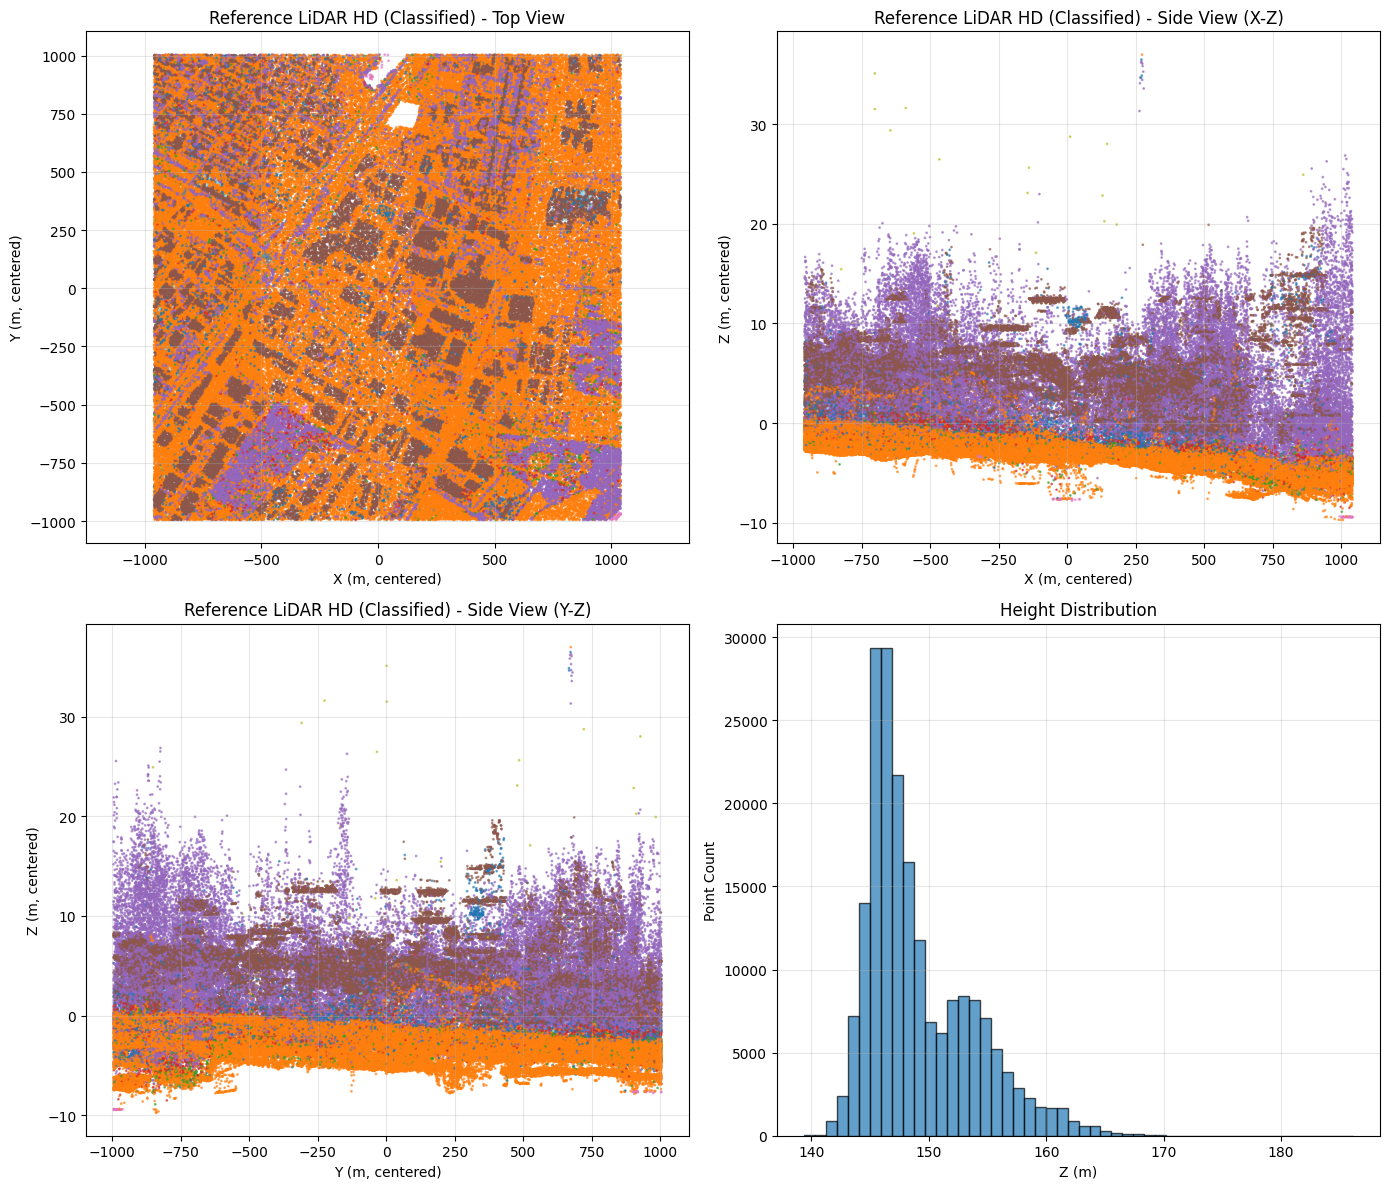

In [7]:
# Visualize raw data
visualize_point_cloud(ref_points_raw, labels=ref_classes_raw, mode='local',
                     title='Reference LiDAR HD (Classified)', subsample=200000, show_2d=True, show_3d=False)

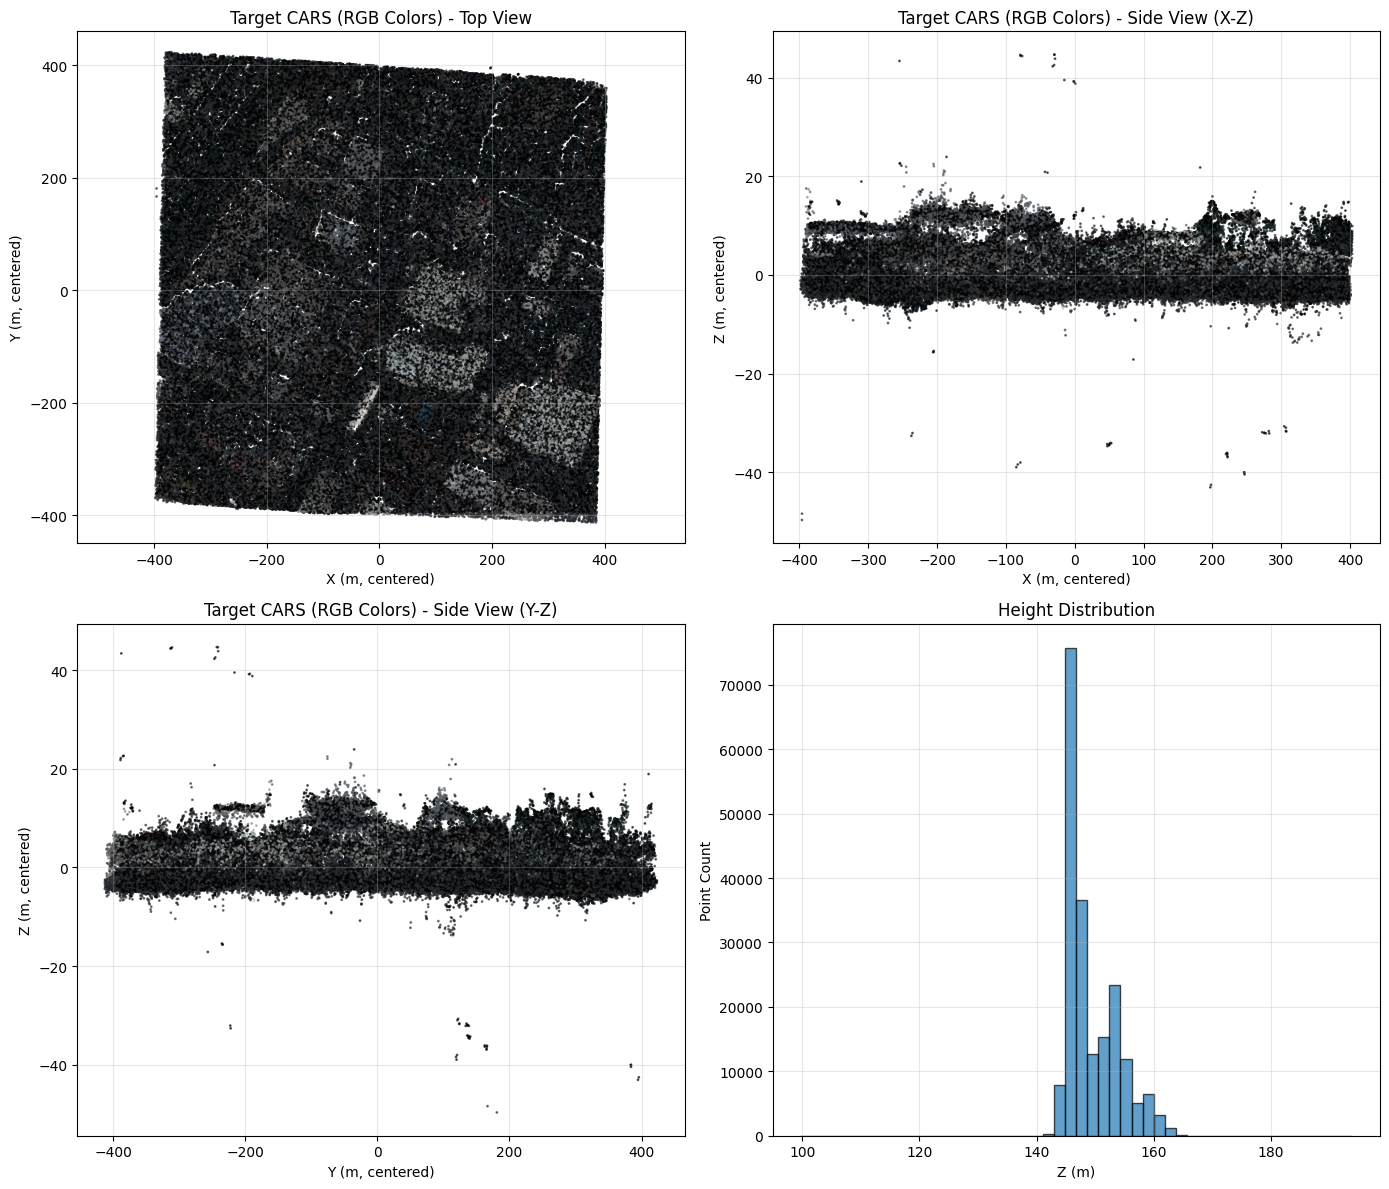

In [8]:
visualize_point_cloud(target_points_raw, colors=target_colors_raw, mode='jupyter',
                     title='Target CARS (RGB Colors)', subsample=200000, show_2d=True, show_3d=False)

---

## Step 3: Pre-processing

Before analysis, we:
1. **Crop** LiDAR to the CARS spatial extent (reduce memory)
2. **Voxel Downsample** both datasets (uniform density)

```
    Voxel Downsampling
    +---------+    +---------+
    | . . . . |    |    *    |   Multiple points
    | . . . . | -> |         |   in same voxel
    | . . . . |    |         |   become one centroid
    +---------+    +---------+
```

> **Why Voxel Downsample?**
> 
> LiDAR HD has ~20 pts/m2, CARS has ~2 pts/m2. Downsampling creates uniform 
> density for fair comparison and reduces computational cost.

> **Florent's Note:** The `VOXEL_SIZE` parameter is crucial. For change detection, I recommend matching the lower-resolution dataset (CARS). A 0.25m voxel preserves building edges while reducing noise. For vegetation analysis, use smaller voxels (0.1m). For large-area analysis, use 0.5-1.0m to manage memory.

**Learn More:** Downsampling strategies are covered in [3D Data Science with Python](https://www.oreilly.com/library/view/3d-data-science/9781098161323/), Chapter 4.

In [9]:
def crop_to_bbox(points, classifications, colors, min_bound, max_bound, margin=0.0):
    """Crop point cloud to bounding box (vectorized)."""
    mask = (
        (points[:, 0] >= min_bound[0] - margin) & (points[:, 0] <= max_bound[0] + margin) &
        (points[:, 1] >= min_bound[1] - margin) & (points[:, 1] <= max_bound[1] + margin) &
        (points[:, 2] >= min_bound[2] - margin) & (points[:, 2] <= max_bound[2] + margin)
    )
    return points[mask], classifications[mask] if classifications is not None else None, colors[mask] if colors is not None else None


def voxel_downsample_fast(points, classifications, colors, voxel_size):
    """Ultra-fast vectorized voxel downsampling."""
    voxel_indices = np.floor(points / voxel_size).astype(np.int64)
    min_idx = voxel_indices.min(axis=0)
    voxel_indices_shifted = voxel_indices - min_idx
    dims = voxel_indices_shifted.max(axis=0) + 1

    linear_idx = (voxel_indices_shifted[:, 0] +
                  voxel_indices_shifted[:, 1] * dims[0] +
                  voxel_indices_shifted[:, 2] * dims[0] * dims[1])

    unique_voxels, inverse, counts = np.unique(linear_idx, return_inverse=True, return_counts=True)
    n_voxels = len(unique_voxels)

    sum_x = np.bincount(inverse, weights=points[:, 0], minlength=n_voxels)
    sum_y = np.bincount(inverse, weights=points[:, 1], minlength=n_voxels)
    sum_z = np.bincount(inverse, weights=points[:, 2], minlength=n_voxels)

    downsampled_points = np.column_stack([sum_x / counts, sum_y / counts, sum_z / counts])
    _, first_indices = np.unique(inverse, return_index=True)
    
    return (downsampled_points, 
            classifications[first_indices] if classifications is not None else None,
            colors[first_indices] if colors is not None else None)

In [10]:
# Get CARS bounding box
cars_min = np.min(target_points_raw, axis=0)
cars_max = np.max(target_points_raw, axis=0)
print(f"CARS extent: X=[{cars_min[0]:.1f}, {cars_max[0]:.1f}], Y=[{cars_min[1]:.1f}, {cars_max[1]:.1f}]")

# Crop LiDAR to CARS extent
print(f"\nCropping LiDAR HD from {len(ref_points_raw):,} points...")
ref_points_cropped, ref_classes_cropped, ref_colors_cropped = crop_to_bbox(
    ref_points_raw, ref_classes_raw, ref_colors_raw, cars_min, cars_max, margin=10.0
)
print(f"  After crop: {len(ref_points_cropped):,} points")

# Voxel downsample
VOXEL_SIZE = 0.25
print(f"\nVoxel downsampling (voxel size = {VOXEL_SIZE}m)...")
ref_points, ref_classes, ref_colors = voxel_downsample_fast(ref_points_cropped, ref_classes_cropped, ref_colors_cropped, VOXEL_SIZE)
target_points, target_classes, target_colors = voxel_downsample_fast(target_points_raw, target_classes_raw, target_colors_raw, VOXEL_SIZE)

print(f"  LiDAR: {len(ref_points_cropped):,} -> {len(ref_points):,} points")
print(f"  CARS:  {len(target_points_raw):,} -> {len(target_points):,} points")

CARS extent: X=[571666.7, 572470.9], Y=[6273808.4, 6274646.0]

Cropping LiDAR HD from 95,526,321 points...
  After crop: 16,224,258 points

Voxel downsampling (voxel size = 0.25m)...
  LiDAR: 16,224,258 -> 11,299,480 points
  CARS:  4,138,419 -> 4,034,393 points


---

## Step 4: Alignment Assessment

Before comparing, we verify the two datasets are properly aligned (same CRS). We compute:
- **Z-shift**: Median vertical offset
- **RMSE**: Root Mean Square Error
- **P95**: 95th percentile error

```
    Z-Error Distribution
    
    Count
      |      ___
      |    _/   \_
      |  _/       \_
      | /           \n      +----------------> Error (m)
           ^-- Median (Z-shift)
```

> **Florent's Note:** If your Z-shift is greater than 1-2m, check your CRS definitions! Common issues: (1) ellipsoidal vs. orthometric heights, (2) different vertical datums (EGM96 vs EGM2008), (3) projection errors. For CARS data, the vertical reference should match your LiDAR's datum. An RMSE < 0.5m indicates excellent alignment for urban change detection.

In [11]:
# Visualize both point clouds together before quality assessment
print("Visualizing both point clouds in same 3D viewer...")

visualize_dual_point_clouds(
    ref_points, target_points,
    name1='LiDAR Reference', name2='CARS Satellite',
    color1=[0.2, 0.6, 0.9], color2=[0.9, 0.3, 0.2],
    subsample=4000000, mode='local'
)

Visualizing both point clouds in same 3D viewer...
Coordinate offset applied: [572086.1, 6274229.7, 149.4]


In [12]:
def assess_alignment(source_pts, target_pts, viz_sample=30000):
    """Vectorized alignment quality assessment with 3D visualization."""
    tree = cKDTree(target_pts)
    dists, idx = tree.query(source_pts, k=1, workers=-1)
    z_diff = source_pts[:, 2] - target_pts[idx, 2]

    valid_mask = np.abs(z_diff) < 10.0
    valid_diff = z_diff[valid_mask]
    z_shift = np.median(valid_diff) if len(valid_diff) > 100 else 0.0

    corrected_diff = z_diff - z_shift
    abs_err = np.abs(corrected_diff)

    stats = {
        'z_shift': z_shift,
        'mean_error': np.mean(abs_err[valid_mask]),
        'rmse': np.sqrt(np.mean(abs_err[valid_mask]**2)),
        'p95_error': np.percentile(abs_err[valid_mask], 95),
        'coverage_2m': np.mean(dists < 2.0) * 100,
    }
    
    print(f"   Z-Shift: {z_shift:.3f}m | RMSE: {stats['rmse']:.3f}m | P95: {stats['p95_error']:.3f}m")

    # Visualization with error coloring
    n = len(source_pts)
    viz_idx = np.random.choice(n, min(viz_sample, n), replace=False)
    err_norm = np.clip(np.abs(corrected_diff[viz_idx]) / 3.0, 0, 1)
    colors = plt.colormaps['RdYlGn_r'](err_norm)[:, :3]
    viz_3d_centered(source_pts[viz_idx], colors, "Alignment Quality (Green=Good, Red=Error)", subsample=viz_sample)

    return z_shift, stats, corrected_diff

In [13]:
print("Alignment Quality Assessment...")
z_shift, align_stats, alignment_errors = assess_alignment(ref_points, target_points, viz_sample=1000000)
target_aligned = target_points.copy()

Alignment Quality Assessment...
   Z-Shift: 0.005m | RMSE: 1.475m | P95: 3.185m


---

## Step 4b: Signed Change Visualization

This visualization shows **directional changes** using LiDAR as reference:

| Color | Meaning | Interpretation |
|:-----:|:--------|:---------------|
| Grey | abs(diff) < 25cm | Stable (no significant change) |
| Red | LiDAR higher | Structure **demolished** (was in LiDAR, gone in CARS) |
| Green | CARS higher | **New construction** (not in LiDAR, appears in CARS) |

```
    LiDAR (Reference)     CARS (Target)
    
       ___                              <- RED: Building demolished
      |   |               ___
      |___|              |   |
    =========          =========
    
                         ___            <- GREEN: New construction
                        |   |
    ___________        |___|
    =========          =========
```

> **Florent's Note:** The `threshold` parameter (default 0.25m) defines what counts as "change". For detecting building changes, 0.5-1.0m works better (buildings are tall). For detecting ground changes (excavation, fill), use 0.25-0.5m. Consider your data's vertical accuracy - don't set threshold below your combined RMSE!

In [14]:
def visualize_signed_changes(ref_pts, target_pts, threshold=0.25, viz_sample=500000):
    """
    Signed change visualization: LiDAR as reference.
    - Grey: |diff| < threshold (no significant change)
    - Red: positive diff (demolished - LiDAR was higher)
    - Green: negative diff (new construction - CARS is higher)
    """
    tree = cKDTree(target_pts)
    dists, idx = tree.query(ref_pts, k=1, workers=-1)
    z_diff = ref_pts[:, 2] - target_pts[idx, 2]

    # Color assignment
    colors = np.full((len(ref_pts), 3), 0.5)  # grey default
    colors[z_diff < -threshold] = [0.2, 0.8, 0.2]  # green = new construction
    colors[z_diff > threshold] = [0.9, 0.2, 0.2]   # red = demolished

    # Subsample and visualize
    n = len(ref_pts)
    idx_viz = np.random.choice(n, min(viz_sample, n), replace=False)
    pts, cols = ref_pts[idx_viz], colors[idx_viz]
    center = pts.mean(axis=0)

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts - center)
    pcd.colors = o3d.utility.Vector3dVector(cols)
    pcd.estimate_normals()
    o3d.visualization.draw_geometries([pcd], window_name="Signed Changes (Grey=stable, Red=demolished, Green=new)")

    demolished = (z_diff > threshold).sum()
    new_const = (z_diff < -threshold).sum()
    stable = (np.abs(z_diff) <= threshold).sum()
    print(f"   Demolished: {demolished:,} | New: {new_const:,} | Stable: {stable:,}")
    
    return z_diff

In [15]:
print("Signed Change Visualization (threshold = 0.25m)...")
z_diff = visualize_signed_changes(ref_points, target_points, threshold=1, viz_sample=1000000)

Signed Change Visualization (threshold = 0.25m)...
   Demolished: 1,290,264 | New: 1,062,619 | Stable: 8,946,597


In [16]:
# Extra: Exclude unclassified (class 1) from LiDAR HD
print("\nFiltered view: Excluding unclassified points (class 1)...")
if ref_classes is not None:
    mask_no_unclass = ref_classes != 1
    ref_pts_filtered = ref_points[mask_no_unclass]
    print(f"   Filtered: {len(ref_pts_filtered):,} / {len(ref_points):,} points")
    visualize_signed_changes(ref_pts_filtered, target_points, threshold=1, viz_sample=1000000)

visualize_dual_point_clouds(
    ref_pts_filtered, target_points,
    name1='LiDAR Reference', name2='CARS Satellite',
    color1=[0.2, 0.6, 0.9], color2=[0.9, 0.3, 0.2],
    subsample=4000000, mode='local'
)


Filtered view: Excluding unclassified points (class 1)...
   Filtered: 10,870,047 / 11,299,480 points
   Demolished: 1,205,359 | New: 1,007,632 | Stable: 8,657,056
Coordinate offset applied: [572086.5, 6274230.0, 149.4]


---

## Step 5: Attribute Transfer (k-NN)

The CARS point cloud has no classification. We **transfer** LiDAR classifications using k-Nearest Neighbors:

```
    LiDAR (with classes)        CARS (no classes)
    
    [Building]  [Ground]   -->   ? ? ? ?
       ^            ^             | | | |
       |            |             v v v v
       +------ k-NN ------+    [Building] [Ground]
```

Points beyond `max_distance` are marked as unclassified (prevents false matches at data boundaries).

> **Florent's Note:** The `max_distance` parameter is your safety net. Set it to ~2x your expected alignment error (e.g., 2.0m if RMSE is ~1m). Points farther than this threshold likely represent real changes, not just spatial offset. For k=1, we use the nearest neighbor's class. Using k=3 or k=5 with majority voting can reduce noise but may smooth boundaries.

In [17]:
def transfer_attributes_knn(source_points, source_attributes, target_points, k_neighbors=1, max_distance=5.0):
    """Transfer attributes from source to target using vectorized k-NN lookup."""
    tree = cKDTree(source_points)
    distances, indices = tree.query(target_points, k=1, workers=-1)
    transferred = source_attributes[indices].copy()
    if max_distance is not None:
        transferred[distances > max_distance] = 0
    return transferred

Attribute Transfer (k-NN)...
Transferred 10 unique classifications to CARS


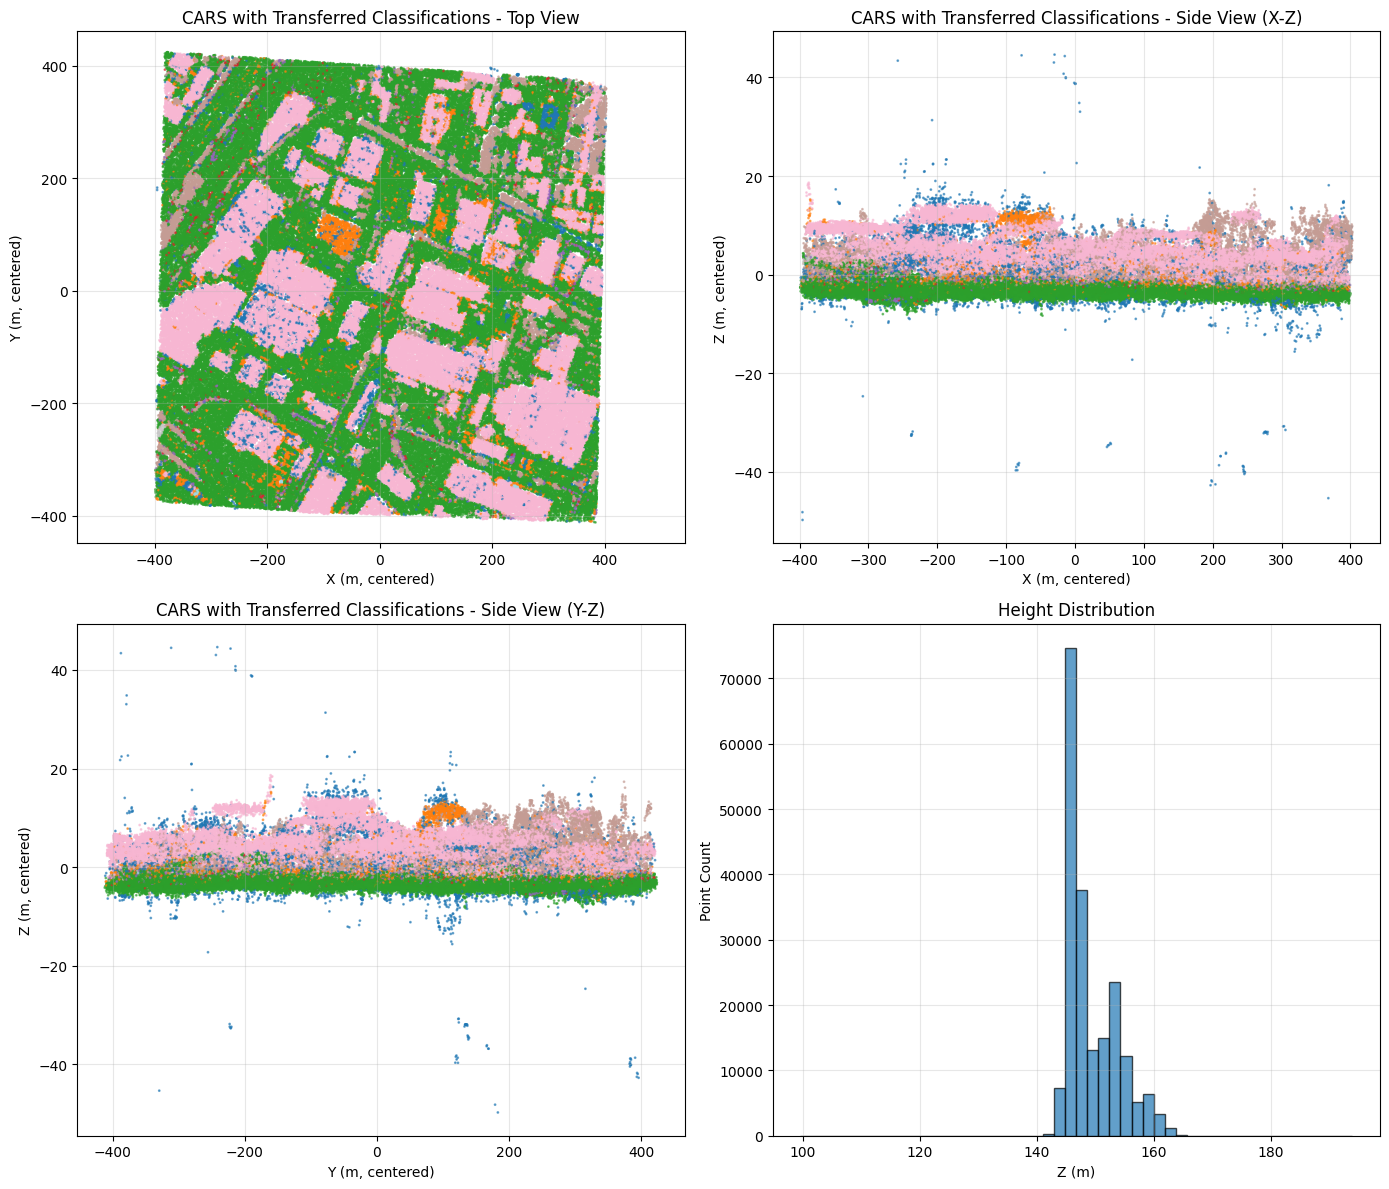

In [18]:
print("Attribute Transfer (k-NN)...")
transferred_classes = None
if ref_classes is not None:
    transferred_classes = transfer_attributes_knn(ref_points, ref_classes, target_points, max_distance=2.0)
    unique_transferred = np.unique(transferred_classes)
    print(f"Transferred {len(unique_transferred)} unique classifications to CARS")
    
    visualize_point_cloud(target_points, labels=transferred_classes, mode='local',
                         title='CARS with Transferred Classifications', subsample=200000, show_2d=True, show_3d=True)

---

## Step 6: DBSCAN Clustering

We segment objects using **DBSCAN** (Density-Based Spatial Clustering):

```
    DBSCAN Parameters
    
    eps = search radius      min_samples = core point threshold
    
        o---o                    o = core point (>=min_samples neighbors)
       /|   |\                   x = border point
      o o   o o                  . = noise
       \|   |/
        o---o
          
    Cluster 1     .  Noise
```

We filter to **analysis classes** (buildings, unclassified) before clustering to focus on change-relevant objects.

> **Florent's Note:** DBSCAN parameter tuning is an art! Start with `eps` = 2x your point spacing (e.g., 2.0m for 1m voxels). `min_samples` controls cluster minimum size - use 30-50 for building detection to filter small noise clusters. If you get too many/few clusters, adjust `eps` first. For elongated objects (roads, walls), consider HDBSCAN which handles varying density better.

**Learn More:** Advanced clustering techniques for 3D data are covered at [learngeodata.eu](https://learngeodata.eu).

In [19]:
# ASPRS LAS Classification Codes
CLASS_GROUND = 2
CLASS_LOW_VEG = 3
CLASS_MED_VEG = 4
CLASS_HIGH_VEG = 5
CLASS_BUILDING = 6
CLASS_NOISE = 7
CLASS_UNCLASSIFIED = 0

ANALYSIS_CLASSES = {CLASS_UNCLASSIFIED, CLASS_BUILDING}


def filter_by_class(points, classification, colors=None, keep_classes=None):
    """Filter points by classification."""
    if classification is None:
        return points, classification, colors
    mask = np.isin(classification, list(keep_classes)) if keep_classes else np.ones(len(points), dtype=bool)
    return points[mask], classification[mask], colors[mask] if colors is not None else None


def cluster_objects(points, eps=2.0, min_samples=30):
    """DBSCAN clustering."""
    if len(points) == 0:
        return np.array([], dtype=np.int32)
    clustering = DBSCAN(eps=eps, min_samples=min_samples, algorithm='ball_tree', n_jobs=-1)
    labels = clustering.fit_predict(points)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"   Found {n_clusters} clusters, {(labels == -1).sum():,} noise points")
    return labels

In [20]:
print("Filtering to analysis classes...")
target_non_ground, target_non_ground_cls, target_non_ground_colors = filter_by_class(
    target_aligned, transferred_classes, target_colors, keep_classes=ANALYSIS_CLASSES
)
ref_non_ground, ref_non_ground_cls, ref_non_ground_colors = filter_by_class(
    ref_points, ref_classes, ref_colors, keep_classes=ANALYSIS_CLASSES
)

print(f"   LiDAR non-ground: {len(ref_non_ground):,} points")
print(f"   CARS non-ground:  {len(target_non_ground):,} points")

print("\nClustering...")
target_cluster_labels = cluster_objects(target_non_ground, eps=2.0, min_samples=30)
ref_cluster_labels = cluster_objects(ref_non_ground, eps=2.0, min_samples=30)

Filtering to analysis classes...
   LiDAR non-ground: 3,029,742 points
   CARS non-ground:  1,396,004 points

Clustering...
   Found 521 clusters, 35,947 noise points
   Found 247 clusters, 13,333 noise points


In [21]:
# Visualize segments
viz_segments_3d(ref_non_ground, ref_cluster_labels, "LiDAR Segments", mode='local')
viz_segments_3d(target_non_ground, target_cluster_labels, "CARS Segments")

---

## Step 7: Feature Extraction (PCA)

We extract **geometric features** from each segment using PCA:

| Feature | Formula | Meaning |
|:--------|:--------|:--------|
| Linearity | (e1 - e2) / e1 | Wire-like (e.g., power lines) |
| Planarity | (e2 - e3) / e1 | Flat surface (e.g., walls, ground) |
| Sphericity | e3 / e1 | Blob-like (e.g., trees) |
| Verticality | abs(n_z) | Vertical alignment |

Where `e1 >= e2 >= e3` are eigenvalues and `n_z` is the Z-component of the principal axis.

> **Florent's Note:** These geometric features are fundamental to 3D scene understanding. Buildings typically show high planarity and moderate verticality. Vegetation shows high sphericity. Linear features like poles and wires show high linearity. These features can be inputs to ML classifiers for automatic object detection! The formulas come from the eigenvalue decomposition of the local covariance matrix.

**Learn More:** PCA-based features and their applications in 3D deep learning are covered extensively in [3D Data Science with Python](https://www.oreilly.com/library/view/3d-data-science/9781098161323/), Chapters 5 and 9.

In [22]:
def extract_segment_features(points):
    """PCA-based geometric feature extraction."""
    if len(points) < 4:
        return {'verticality': 0, 'planarity': 0, 'linearity': 0, 'sphericity': 0, 'height': 0}
    centered = points - points.mean(axis=0)
    cov = np.cov(centered.T)
    eigenvalues = np.maximum(np.linalg.eigvalsh(cov)[::-1], 1e-10)
    e1, e2, e3 = eigenvalues
    return {
        'verticality': np.abs(np.linalg.eigh(cov)[1][:, -1][2]),
        'planarity': (e2 - e3) / e1,
        'linearity': (e1 - e2) / e1,
        'sphericity': e3 / e1,
        'height': points[:, 2].max() - points[:, 2].min()
    }


def compute_segment_properties(segment_points):
    """Calculate geometric properties of a segment."""
    return {
        'centroid': segment_points.mean(axis=0),
        'min_bound': segment_points.min(axis=0),
        'max_bound': segment_points.max(axis=0),
        'num_points': len(segment_points)
    }


def compute_cluster_stats(points, labels):
    """Compute statistics for all clusters."""
    unique_labels = np.unique(labels[labels >= 0])
    stats = []
    for lbl in unique_labels:
        mask = labels == lbl
        cluster_pts = points[mask]
        stats.append({
            'label': lbl, 'count': mask.sum(), 'centroid': cluster_pts.mean(axis=0),
            'bbox_min': cluster_pts.min(axis=0), 'bbox_max': cluster_pts.max(axis=0),
            'height': cluster_pts[:, 2].max() - cluster_pts[:, 2].min()
        })
    return stats

In [23]:
# Build segment dictionaries
ref_cluster_stats = compute_cluster_stats(ref_non_ground, ref_cluster_labels)
cluster_stats = compute_cluster_stats(target_non_ground, target_cluster_labels)

ref_segments, target_segments = {}, {}
for stat in ref_cluster_stats:
    lbl = stat['label']
    mask = ref_cluster_labels == lbl
    ref_segments[lbl] = {'points': ref_non_ground[mask], 'mask': mask, 'size': stat['count'], 'properties': stat}
for stat in cluster_stats:
    lbl = stat['label']
    mask = target_cluster_labels == lbl
    target_segments[lbl] = {'points': target_non_ground[mask], 'mask': mask, 'size': stat['count'], 'properties': stat}

# Extract features
ref_features = {seg_id: extract_segment_features(seg_data['points']) for seg_id, seg_data in ref_segments.items()}
target_features = {seg_id: extract_segment_features(seg_data['points']) for seg_id, seg_data in target_segments.items()}

print(f"Extracted features for {len(ref_features)} LiDAR segments and {len(target_features)} CARS segments")

Extracted features for 247 LiDAR segments and 521 CARS segments


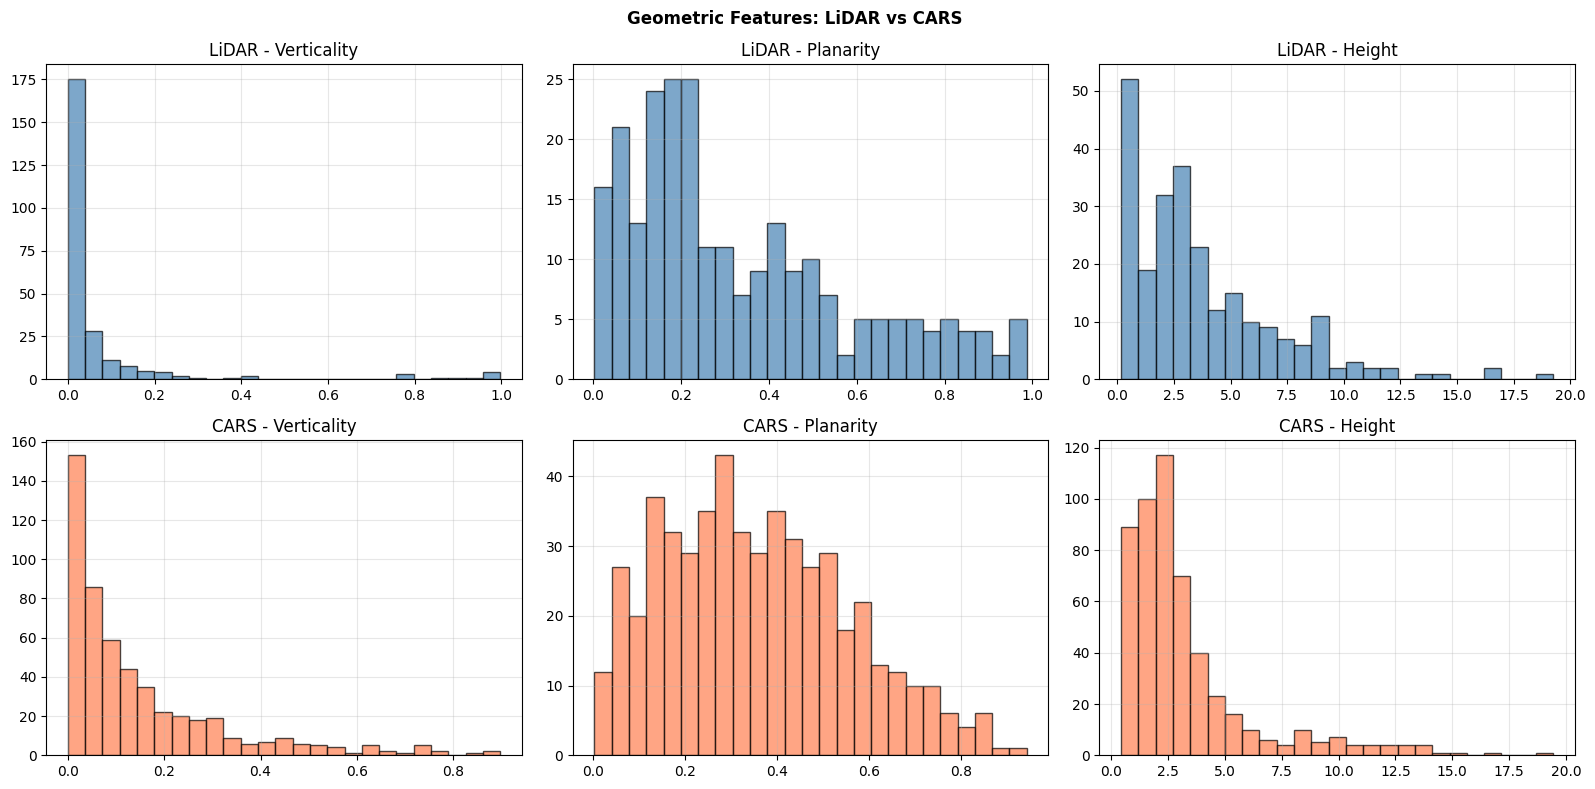

In [24]:
# Feature comparison histograms
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
ref_verts = np.array([f['verticality'] for f in ref_features.values()])
ref_plans = np.array([f['planarity'] for f in ref_features.values()])
ref_heights = np.array([f['height'] for f in ref_features.values()])
target_verts = np.array([f['verticality'] for f in target_features.values()])
target_plans = np.array([f['planarity'] for f in target_features.values()])
target_heights = np.array([f['height'] for f in target_features.values()])

for ax, data, title in zip(axes[0], [ref_verts, ref_plans, ref_heights], ['Verticality', 'Planarity', 'Height']):
    ax.hist(data, bins=25, alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_title(f'LiDAR - {title}')
    ax.grid(True, alpha=0.3)
for ax, data, title in zip(axes[1], [target_verts, target_plans, target_heights], ['Verticality', 'Planarity', 'Height']):
    ax.hist(data, bins=25, alpha=0.7, color='coral', edgecolor='black')
    ax.set_title(f'CARS - {title}')
    ax.grid(True, alpha=0.3)
plt.suptitle('Geometric Features: LiDAR vs CARS', fontweight='bold')
plt.tight_layout()
plt.show()

---

## Step 8: Change Zone Detection

We identify **real changes** vs **CARS noise** by analyzing height difference **consistency** within segments:

| Scenario | Mean Error | Consistency | Classification |
|:---------|:----------:|:-----------:|:---------------|
| Real change | High | High (>70% same direction) | **Change detected** |
| CARS noise | High | Low (mixed +/-) | Noise (ignore) |
| Stable | Low | N/A | No change |

```
    Real Change               CARS Noise
    (Consistent)              (Inconsistent)
    
    + + + + + +               + - + - + -
    + + + + + +               - + - + - +
    + + + + + +               + - + - + -
    
    All positive              Mixed directions
    = demolished              = measurement error
```

> **Florent's Note:** This consistency check is key to robust change detection! Satellite-derived point clouds often have "bumpy" noise patterns where adjacent points randomly jump up/down. Real changes (demolitions, constructions) show consistent direction across the segment. The 70% threshold works well for urban areas - you may need to adjust for different land cover types. For vegetation-heavy areas, consider seasonal effects!

In [25]:
def identify_change_segments(ref_non_ground, ref_cluster_labels, height_diffs, error_threshold=2.0, consistency_threshold=0.7):
    """Identify segments with consistent height difference (real change vs CARS noise)."""
    segment_errors = {}
    unique_labels = np.unique(ref_cluster_labels[ref_cluster_labels >= 0])

    for lbl in unique_labels:
        mask = ref_cluster_labels == lbl
        seg_diffs = height_diffs[mask]
        mean_diff = np.mean(seg_diffs)
        abs_mean = np.abs(mean_diff)
        n_positive = (seg_diffs > 0.5).sum()
        n_negative = (seg_diffs < -0.5).sum()
        n_total = len(seg_diffs)
        consistency = max(n_positive, n_negative) / n_total if n_total > 0 else 0
        is_real_change = abs_mean > error_threshold and consistency > consistency_threshold
        is_cars_noise = abs_mean > error_threshold and consistency <= consistency_threshold

        segment_errors[lbl] = {
            'mean_diff': mean_diff, 'abs_mean': abs_mean, 'consistency': consistency,
            'is_change': is_real_change, 'is_noise': is_cars_noise,
            'change_type': 'real_change' if is_real_change else ('cars_noise' if is_cars_noise else 'stable')
        }

    real_changes = [lbl for lbl, e in segment_errors.items() if e['is_change']]
    noise_segments = [lbl for lbl, e in segment_errors.items() if e['is_noise']]
    print(f"   {len(real_changes)} real changes | {len(noise_segments)} CARS noise | {len(unique_labels) - len(real_changes) - len(noise_segments)} stable")
    return segment_errors, real_changes

In [26]:
# Compute alignment errors for non-ground points
tree_ng = cKDTree(target_non_ground)
_, idx_ng = tree_ng.query(ref_non_ground, k=1, workers=-1)
alignment_errors_ng = ref_non_ground[:, 2] - target_non_ground[idx_ng, 2]

print("Change Zone Detection...")
segment_errors, changed_segment_ids = identify_change_segments(
    ref_non_ground, ref_cluster_labels, alignment_errors_ng, error_threshold=1.5
)

Change Zone Detection...
   49 real changes | 7 CARS noise | 191 stable


In [27]:
# Visualize: Real changes (red), CARS noise (yellow), Stable (green)
change_colors = np.full((len(ref_non_ground), 3), 0.5)
for lbl, err_data in segment_errors.items():
    mask = ref_cluster_labels == lbl
    if err_data['is_change']:
        change_colors[mask] = [0.9, 0.2, 0.2]  # Red
    elif err_data['is_noise']:
        change_colors[mask] = [0.9, 0.7, 0.2]  # Yellow
    else:
        change_colors[mask] = [0.3, 0.7, 0.3]  # Green

viz_3d_centered(ref_non_ground, change_colors, "Changes: Red=Real, Yellow=CARS Noise, Green=Stable")

---

## Step 9: Important Change Classification

We classify detected changes into actionable categories:
- **New Structure**: CARS higher than LiDAR (building constructed)
- **Removed Structure**: LiDAR higher than CARS (building demolished)

```
    CHANGE CLASSIFICATION LOGIC
    
    For each segment with consistent change:
    
    IF mean(Z_lidar - Z_cars) > threshold:
        --> REMOVED (demolition)
        Color: RED
    
    IF mean(Z_lidar - Z_cars) < -threshold:
        --> NEW (construction)
        Color: GREEN
```

> **Florent's Note:** The `min_height_diff` and `min_segment_size` filters are your quality controls. `min_height_diff=2.0m` filters out small changes (cars, temporary structures). `min_segment_size=50` removes tiny noise clusters. For monitoring construction sites, lower these thresholds. For detecting only major building changes, increase them.

**Learn More:** Change detection workflows and quality metrics are detailed at [learngeodata.eu](https://learngeodata.eu).

In [28]:
def classify_important_changes(changed_segment_ids, segment_errors, ref_segments, min_height_diff=2.0, min_segment_size=50):
    """Classify only IMPORTANT changes - ignore CARS noise."""
    important_changes = []
    for seg_id in changed_segment_ids:
        if seg_id not in segment_errors or seg_id not in ref_segments:
            continue
        err, seg = segment_errors[seg_id], ref_segments[seg_id]
        if seg['size'] < min_segment_size or err['abs_mean'] < min_height_diff:
            continue
        change_type = 'removed_structure' if err['mean_diff'] > 0 else 'new_structure'
        important_changes.append({
            'segment_id': seg_id, 'change_type': change_type,
            'height_diff': err['mean_diff'], 'consistency': err['consistency'],
            'centroid': seg['properties']['centroid'], 'size': seg['size']
        })
    return important_changes

In [29]:
# Add semantic labels to reference segments
for seg_id, seg_data in ref_segments.items():
    seg_classes = ref_non_ground_cls[seg_data['mask']]
    unique, counts = np.unique(seg_classes, return_counts=True)
    seg_data['semantic_label'] = int(unique[counts.argmax()])

important_changes = classify_important_changes(changed_segment_ids, segment_errors, ref_segments, min_height_diff=2.0, min_segment_size=50)

new_structures = [c for c in important_changes if c['change_type'] == 'new_structure']
removed_structures = [c for c in important_changes if c['change_type'] == 'removed_structure']

print(f"Important Changes:")
print(f"   New structures: {len(new_structures)}")
print(f"   Removed structures: {len(removed_structures)}")

Important Changes:
   New structures: 14
   Removed structures: 23


In [30]:
# Visualize important changes
IMPORTANT_COLORS = {'new_structure': [0.2, 0.8, 0.2], 'removed_structure': [0.8, 0.2, 0.2]}
important_colors = np.tile([0.4, 0.4, 0.4], (len(ref_non_ground), 1))
for c in important_changes:
    mask = ref_cluster_labels == c['segment_id']
    important_colors[mask] = IMPORTANT_COLORS[c['change_type']]

viz_3d_centered(ref_non_ground, important_colors, "Important Changes: Green=New, Red=Removed")

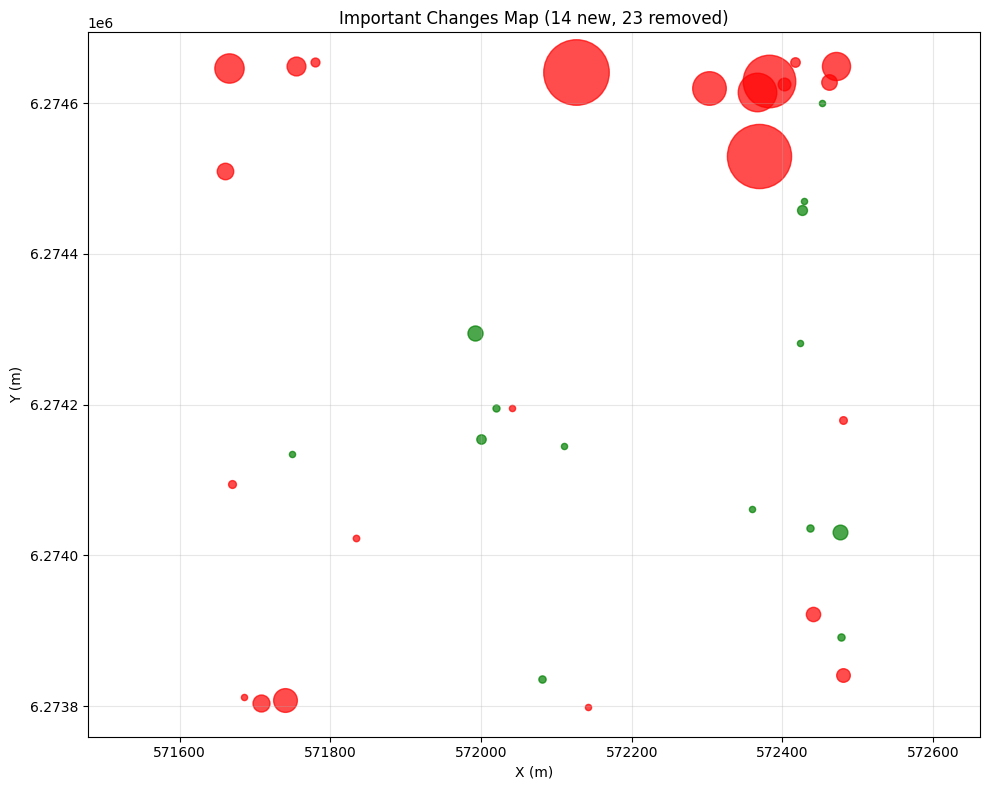

In [31]:
# 2D Change Map
if important_changes:
    fig, ax = plt.subplots(figsize=(10, 8))
    for c in important_changes:
        color = 'green' if c['change_type'] == 'new_structure' else 'red'
        ax.scatter(c['centroid'][0], c['centroid'][1], c=color, s=max(20, c['size']/10), alpha=0.7)
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_title(f"Important Changes Map ({len(new_structures)} new, {len(removed_structures)} removed)")
    ax.axis('equal')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

---

## Step 10: 3D Building Mesh Generation

For detected changes, we create **3D building meshes** using a multi-step process:

```
    BUILDING MESH GENERATION PIPELINE
    
    [1] Extract Roof          [2] PCA Alignment        [3] Grid Projection
    
        . . . .                   /                      +---+---+---+
       . . . . .                 /  aligned             +---+---+---+
        . . . .                 /   axes                +---+---+---+
       (top 15%)               ------->                  (fill holes)
    
    [4] Triangulation         [5] Wall Extrusion       [6] Final Mesh
    
       /\    /\                  _________                _________
      /  \  /  \                |         |              |         |
     /----\/----\               |   |  |  |              |         |
     (Delaunay)                 |___|__|__|              |_________|
                                (boundary)               (watertight)
```

**Algorithm Steps:**
1. **Extract roof points** - Select top percentile (85th) of segment
2. **PCA-align** - Rotate to building's principal orientation
3. **Project to grid** - Create 2D occupancy grid and fill holes
4. **Delaunay triangulation** - Generate roof surface triangles
5. **Extrude walls** - Create vertical faces to ground level
6. **Close mesh** - Add floor and ensure watertight geometry

> **Florent's Note:** The `grid_res` parameter controls mesh detail vs. file size. Use 0.5m for detailed visualization, 2.0m for lightweight exports. For photogrammetric point clouds with more noise, increase the grid resolution to smooth out artifacts.

**Learn More:** This mesh generation technique is covered in depth in [3D Data Science with Python](https://www.oreilly.com/library/view/3d-data-science/9781098161323/), Chapter 8.

In [32]:
def create_building_mesh(segment_pts, bottom_cloud, grid_res=0.5, is_destroyed=True):
    """Creates a building mesh aligned with the building's orientation."""
    z_thresh = np.percentile(segment_pts[:, 2], 85)
    top_pts = segment_pts[segment_pts[:, 2] >= z_thresh]
    if len(top_pts) < 4:
        return None

    roof_z = np.median(top_pts[:, 2])
    ground_z = np.percentile(bottom_cloud[:, 2], 10) if len(bottom_cloud) > 0 else segment_pts[:, 2].min()

    # PCA alignment
    pts_raw_2d = top_pts[:, :2]
    center_2d = pts_raw_2d.mean(axis=0)
    cov = np.cov((pts_raw_2d - center_2d).T)
    eig_vals, eig_vecs = np.linalg.eigh(cov)
    angle = np.arctan2(eig_vecs[:, np.argmax(eig_vals)][1], eig_vecs[:, np.argmax(eig_vals)][0])

    c, s = np.cos(-angle), np.sin(-angle)
    R_align = np.array([[c, -s], [s, c]])
    pts_aligned = (pts_raw_2d - center_2d) @ R_align.T + center_2d

    # Grid projection
    min_xy, max_xy = pts_aligned.min(axis=0), pts_aligned.max(axis=0)
    width = int(np.ceil((max_xy[0] - min_xy[0]) / grid_res)) + 2
    height = int(np.ceil((max_xy[1] - min_xy[1]) / grid_res)) + 2
    grid = np.zeros((width, height), dtype=bool)
    idx_x = np.clip(((pts_aligned[:, 0] - min_xy[0]) / grid_res).astype(int), 0, width - 1)
    idx_y = np.clip(((pts_aligned[:, 1] - min_xy[1]) / grid_res).astype(int), 0, height - 1)
    grid[idx_x, idx_y] = True
    filled_grid = binary_fill_holes(grid)

    # Generate mesh vertices
    xs, ys = np.where(filled_grid)
    pts_mesh_aligned = np.column_stack((min_xy[0] + xs * grid_res, min_xy[1] + ys * grid_res))

    # Triangulate
    tri = Delaunay(pts_mesh_aligned)
    valid_simplices, edge_counter = [], {}
    max_edge_len = grid_res * 1.5
    for simplex in tri.simplices:
        pts = pts_mesh_aligned[simplex]
        if max(np.linalg.norm(pts[0]-pts[1]), np.linalg.norm(pts[1]-pts[2]), np.linalg.norm(pts[2]-pts[0])) < max_edge_len:
            valid_simplices.append(simplex)
            for i in range(3):
                edge = tuple(sorted([simplex[i], simplex[(i + 1) % 3]]))
                edge_counter[edge] = edge_counter.get(edge, 0) + 1
    if not valid_simplices:
        return None

    # Rotate back to world
    c_back, s_back = np.cos(angle), np.sin(angle)
    R_back = np.array([[c_back, -s_back], [s_back, c_back]])
    pts_mesh_world = (pts_mesh_aligned - center_2d) @ R_back.T + center_2d

    # Build 3D mesh
    n_verts = len(pts_mesh_world)
    roof_verts = np.column_stack([pts_mesh_world, np.full(n_verts, roof_z)])
    floor_verts = np.column_stack([pts_mesh_world, np.full(n_verts, ground_z)])
    all_vertices = np.vstack([roof_verts, floor_verts])

    faces = list(valid_simplices)
    for tri_idx in valid_simplices:
        faces.append([tri_idx[0] + n_verts, tri_idx[2] + n_verts, tri_idx[1] + n_verts])
    for p1, p2 in [e for e, count in edge_counter.items() if count == 1]:
        faces.append([p1, p1 + n_verts, p2 + n_verts])
        faces.append([p1, p2 + n_verts, p2])

    mesh = o3d.geometry.TriangleMesh()
    mesh.vertices = o3d.utility.Vector3dVector(all_vertices)
    mesh.triangles = o3d.utility.Vector3iVector(np.array(faces))
    mesh.compute_vertex_normals()
    mesh.paint_uniform_color([0.9, 0.2, 0.2] if is_destroyed else [0.2, 0.9, 0.2])
    return mesh

def extract_region_data(segment_id, ref_segments, ref_points, ref_classes, target_points, target_colors, margin=30.0):
    """Extract region data for modeling."""
    seg_pts = ref_segments[segment_id]['points']
    bbox_min, bbox_max = seg_pts.min(axis=0) - margin, seg_pts.max(axis=0) + margin
    lidar_mask = ((ref_points >= bbox_min) & (ref_points <= bbox_max)).all(axis=1)
    cars_mask = ((target_points >= bbox_min) & (target_points <= bbox_max)).all(axis=1)
    low_mask = ((ref_points >= bbox_min + margin - 5) & (ref_points <= bbox_max - margin + 5)).all(axis=1)
    return {
        'segment': seg_pts,
        'lidar': ref_points[lidar_mask], 'lidar_cls': ref_classes[lidar_mask] if ref_classes is not None else None,
        'cars': target_points[cars_mask], 'cars_colors': target_colors[cars_mask] if target_colors is not None else None,
        'low_points': ref_points[low_mask], 'center': seg_pts.mean(axis=0)
    }

In [35]:
INTERACTIVE_SELECT = True
building_meshes = []

if INTERACTIVE_SELECT and OPEN3D_AVAILABLE:
    cmap = plt.colormaps['tab20']
    colors = np.full((len(ref_non_ground), 3), 0.3)
    valid = ref_cluster_labels >= 0
    colors[valid] = cmap((ref_cluster_labels[valid] % 20) / 19.0)[:, :3]

    center_select = ref_non_ground.mean(axis=0)
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(ref_non_ground - center_select)
    pcd.colors = o3d.utility.Vector3dVector(colors)

    vis = o3d.visualization.VisualizerWithEditing()
    vis.create_window(window_name="Select segment (Shift+Click, then Q)")
    vis.add_geometry(pcd)
    vis.run()
    picked = vis.get_picked_points()
    vis.destroy_window()

    selected_id = ref_cluster_labels[picked[-1]] if picked else None
else:
    selected_change = max(important_changes, key=lambda c: abs(c['height_diff']))
    selected_id = selected_change['segment_id']

print(selected_id)

[Open3D INFO] Picked point #342841 (2.5e+02, 3.3e+02, -4.4) to add in queue.
23


In [37]:
region = extract_region_data(selected_id, ref_segments, ref_points, ref_classes, target_aligned, target_colors, margin=30.0)
center = region['center']

segment_pts = region['segment']
bottom_cloud = region['low_points']

# Create building mesh
building_mesh = create_building_mesh(segment_pts, bottom_cloud, grid_res=2, is_destroyed=True)
viz_multimodal([building_mesh], "Building Modelling", center)

In [38]:
# Multimodal: mesh + segment (yellow) + LiDAR (classified)
pcd_seg = o3d.geometry.PointCloud()
pcd_seg.points = o3d.utility.Vector3dVector(segment_pts)
pcd_seg.paint_uniform_color([1.0, 1.0, 0.0])

pcd_lidar = o3d.geometry.PointCloud()
pcd_lidar.points = o3d.utility.Vector3dVector(region['lidar'])
CLASS_COLORS = {0:[.5,.5,.5], 2:[.6,.4,.2], 3:[.5,.8,.3], 4:[.3,.7,.3], 5:[.1,.5,.1], 6:[.8,.3,.3], 7:[.2,.2,.2]}

pcd_lidar.colors = o3d.utility.Vector3dVector([CLASS_COLORS.get(int(c), [.5,.5,.5]) for c in region['lidar_cls']])

viz_multimodal([building_mesh, pcd_seg, pcd_lidar], "Mesh + Segment (yellow) + LiDAR", center)

In [39]:
# Select the most significant change for modeling
if important_changes:
    selected_change = max(important_changes, key=lambda c: abs(c['height_diff']))
    selected_id = selected_change['segment_id']
    selected_id = 23
    is_destroyed = selected_change['change_type'] == 'removed_structure'

    region = extract_region_data(selected_id, ref_segments, ref_points, ref_classes, target_aligned, target_colors, margin=30.0)
    center = region['center']

    print(f"Creating building mesh for segment {selected_id}...")
    print(f"   Type: {'Demolished' if is_destroyed else 'New Construction'}")
    print(f"   Height diff: {selected_change['height_diff']:.2f}m")

    building_mesh = create_building_mesh(region['segment'], region['low_points'], grid_res=2, is_destroyed=is_destroyed)
    if building_mesh:
        print(f"   Triangles: {len(np.asarray(building_mesh.triangles))}")
        viz_multimodal([building_mesh], f"Building ({'Demolished' if is_destroyed else 'New'})", center)
else:
    print("No important changes detected for mesh generation")

Creating building mesh for segment 23...
   Type: Demolished
   Height diff: 10.72m
   Triangles: 1572


---

## Step 11a: DSM Mesh with Classification Colors

We create a **Digital Surface Model (DSM)** mesh representing the top surface of all objects:

```
    DSM GENERATION
    
    Point Cloud                    2D Grid (max Z)              Triangulated DSM
    
      .  .    .                    +----+----+----+              /\    /\n     . .. .  . .                   | 45 | 47 | 42 |             /  \  /  \n      .  . ..  .      ------>      +----+----+----+   ----->   /----\/----\n     .  . .   .                    | 12 | 15 | 14 |           /      \      \n      . .  . .                     +----+----+----+          (colored surface)
    
    (3D points)                   (height values)            (mesh + colors)
```

**Classification Color Scheme (ASPRS LAS 1.4):**

| Class | Color | Description |
|:-----:|:------|:------------|
| 0 | Grey | Unclassified |
| 2 | Brown | Ground |
| 3-5 | Green shades | Vegetation (Low/Med/High) |
| 6 | Red-ish | Building |
| 7 | Dark grey | Noise |

> **Florent's Note:** The DSM resolution (`resolution` parameter) should match your point cloud density. For LiDAR HD (~20 pts/m2), use 0.25-0.5m. For CARS (~2 pts/m2), use 1-2m. Too fine a resolution creates holes; too coarse loses detail.

In [40]:
def create_dsm_mesh(points, resolution=0.5):
    """Creates a single-layer top surface (DSM) mesh."""
    if len(points) < 4:
        return None
    min_x, min_y = points[:, :2].min(axis=0)
    max_x, max_y = points[:, :2].max(axis=0)
    x_bins = np.arange(min_x, max_x + resolution, resolution)
    y_bins = np.arange(min_y, max_y + resolution, resolution)
    if len(x_bins) < 2 or len(y_bins) < 2:
        return None

    grid_z, _, _, _ = binned_statistic_2d(points[:, 0], points[:, 1], points[:, 2], statistic='max', bins=[x_bins, y_bins])
    mask = np.isnan(grid_z)
    if mask.any():
        indices = distance_transform_edt(mask, return_distances=False, return_indices=True)
        grid_z = grid_z[tuple(indices)]

    nx, ny = grid_z.shape
    xc, yc = x_bins[:-1] + resolution / 2, y_bins[:-1] + resolution / 2
    xv, yv = np.meshgrid(xc, yc, indexing='ij')
    vertices = np.column_stack([xv.ravel(), yv.ravel(), grid_z.ravel()])

    ids = np.arange(nx * ny).reshape(nx, ny)
    tl, tr, bl, br = ids[:-1, :-1].ravel(), ids[:-1, 1:].ravel(), ids[1:, :-1].ravel(), ids[1:, 1:].ravel()
    faces = np.vstack([np.column_stack([tl, bl, tr]), np.column_stack([tr, bl, br])])

    mesh = o3d.geometry.TriangleMesh()
    mesh.vertices = o3d.utility.Vector3dVector(vertices)
    mesh.triangles = o3d.utility.Vector3iVector(faces)
    mesh.compute_vertex_normals()
    return mesh


def paint_dsm_with_classification(mesh, ref_pts, ref_cls, class_colors):
    """Paint DSM mesh vertices using nearest classification from reference."""
    verts = np.asarray(mesh.vertices)
    tree = cKDTree(ref_pts)
    _, idx = tree.query(verts, k=1, workers=-1)
    vert_cls = ref_cls[idx]
    colors = np.array([class_colors.get(int(c), [0.5, 0.5, 0.5]) for c in vert_cls])
    mesh.vertex_colors = o3d.utility.Vector3dVector(colors)

In [41]:
# Create DSM mesh for the selected region
if 'region' in dir():
    all_pts = np.vstack([region['lidar'], region['cars']]) if len(region['cars']) > 0 else region['lidar']
    dsm_mesh = create_dsm_mesh(all_pts, resolution=0.5)

    DSM_CLASS_COLORS = {
        0: [.5, .5, .5], 1: [.7, .7, .7], 2: [.6, .4, .2],
        3: [.5, .8, .3], 4: [.3, .7, .3], 5: [.1, .5, .1],
        6: [.8, .3, .3], 7: [.2, .2, .2]
    }
    paint_dsm_with_classification(dsm_mesh, region['lidar'], region['lidar_cls'], DSM_CLASS_COLORS)
    print(f"DSM Mesh: {len(np.asarray(dsm_mesh.triangles))} triangles")
    viz_multimodal([dsm_mesh], "DSM Mesh (Classification-Colored)", center)

DSM Mesh: 87234 triangles


---

## Step 11b: 3D Zone Voxelization

Voxelization converts the point cloud into a **regular 3D grid** of cubes, useful for volumetric analysis and visualization:

```
    VOXELIZATION PROCESS
    
    Point Cloud              Voxel Grid                Colored Voxel Mesh
    
      .  .  .                +--+--+--+                 [B][B][V]
     . .. .  .               |  |##|  |                 [B][B][G]
      . . .  .    ------>    +--+--+--+     ------>     [G][G][G]
     . . . . .               |##|##|  |                   ^
      . . . .                +--+--+--+                 (classification
                                                          colors)
    
    Legend: ## = occupied voxel
            B = Building (grey-blue)
            V = Vegetation (green)
            G = Ground (brown)
```

**Color Coding for Changes:**
- **Blue**: New structure (appeared in CARS, not in LiDAR)
- **Purple**: Removed structure (was in LiDAR, gone in CARS)
- **Standard colors**: Stable areas (classification-based)

> **Florent's Note:** Voxel size is a critical parameter. 1m voxels work well for building-scale analysis. For detecting smaller changes (vehicles, construction equipment), use 0.25-0.5m. Memory usage scales cubically with resolution!

In [42]:
# Classification color scheme
VOXEL_CLASS_COLORS = {
    0: [0.5, 0.5, 0.5],   # Unclassified - grey
    2: [0.6, 0.4, 0.2],   # Ground - brown
    3: [0.5, 0.8, 0.3],   # Low vegetation - light green
    4: [0.3, 0.7, 0.3],   # Medium vegetation - green
    5: [0.1, 0.5, 0.1],   # High vegetation - dark green
    6: [0.7, 0.7, 0.8],   # Building - light grey
    7: [0.2, 0.2, 0.2],   # Noise - dark grey
    10: [0.3, 0.3, 0.9],  # New structure (added) - blue
    11: [0.7, 0.3, 0.9],  # Removed structure (destroyed) - purple
}

def voxelize_with_classification(points, classifications, voxel_size=1.0):
    """Voxelize with majority classification per voxel."""
    if len(points) < 10:
        return None, None, None

    pts_min = points.min(axis=0)
    voxel_idx = np.floor((points - pts_min) / voxel_size).astype(np.int32)

    # Create voxel key for each point
    dims = voxel_idx.max(axis=0) + 1
    linear_idx = voxel_idx[:, 0] + voxel_idx[:, 1] * dims[0] + voxel_idx[:, 2] * dims[0] * dims[1]

    # Find unique voxels
    unique_linear, inverse = np.unique(linear_idx, return_inverse=True)

    # Compute voxel centers
    voxel_coords = np.column_stack([
        unique_linear % dims[0],
        (unique_linear // dims[0]) % dims[1],
        unique_linear // (dims[0] * dims[1])
    ])
    voxel_centers = pts_min + voxel_coords * voxel_size + voxel_size / 2

    # Majority vote for classification per voxel
    n_voxels = len(unique_linear)
    voxel_classes = np.zeros(n_voxels, dtype=np.int32)
    for i in range(n_voxels):
        mask = inverse == i
        if classifications is not None:
            classes_in_voxel = classifications[mask]
            unique_cls, counts = np.unique(classes_in_voxel, return_counts=True)
            voxel_classes[i] = unique_cls[counts.argmax()]

    return voxel_centers, voxel_size, voxel_classes


def voxels_to_colored_mesh(voxel_centers, voxel_size, voxel_classes, change_mask=None, is_destroyed=True):
    """Convert voxels to mesh with per-voxel colors based on classification."""
    if voxel_centers is None or len(voxel_centers) == 0:
        return None

    # Build occupied set
    scale = 1.0 / voxel_size
    voxel_keys = np.round(voxel_centers * scale).astype(int)
    occupied = set(map(tuple, voxel_keys))

    hs = voxel_size / 2
    # Face templates: vertices, indices, neighbor offset
    face_defs = [
        (np.array([[-hs,-hs, hs],[ hs,-hs, hs],[ hs, hs, hs],[-hs, hs, hs]]), [0,1,2,0,2,3], (0,0,1)),   # top
        (np.array([[-hs,-hs,-hs],[-hs, hs,-hs],[ hs, hs,-hs],[ hs,-hs,-hs]]), [0,1,2,0,2,3], (0,0,-1)), # bottom
        (np.array([[-hs, hs,-hs],[-hs, hs, hs],[ hs, hs, hs],[ hs, hs,-hs]]), [0,1,2,0,2,3], (0,1,0)),  # front
        (np.array([[-hs,-hs,-hs],[ hs,-hs,-hs],[ hs,-hs, hs],[-hs,-hs, hs]]), [0,1,2,0,2,3], (0,-1,0)), # back
        (np.array([[ hs,-hs,-hs],[ hs, hs,-hs],[ hs, hs, hs],[ hs,-hs, hs]]), [0,1,2,0,2,3], (1,0,0)),  # right
        (np.array([[-hs,-hs,-hs],[-hs,-hs, hs],[-hs, hs, hs],[-hs, hs,-hs]]), [0,1,2,0,2,3], (-1,0,0)), # left
    ]

    all_verts, all_faces, all_colors = [], [], []
    vert_offset = 0

    for i, (ctr, vkey) in enumerate(zip(voxel_centers, voxel_keys)):
        # Determine color
        cls = voxel_classes[i] if voxel_classes is not None else 0
        if change_mask is not None and change_mask[i]:
            color = VOXEL_CLASS_COLORS[11 if is_destroyed else 10]
        else:
            color = VOXEL_CLASS_COLORS.get(cls, [0.5, 0.5, 0.5])

        vkey_tuple = tuple(vkey)
        for verts_rel, idx, offset in face_defs:
            neighbor = (vkey_tuple[0]+offset[0], vkey_tuple[1]+offset[1], vkey_tuple[2]+offset[2])
            if neighbor in occupied:
                continue
            verts = ctr + verts_rel
            all_verts.extend(verts)
            all_faces.append([vert_offset + idx[0], vert_offset + idx[1], vert_offset + idx[2]])
            all_faces.append([vert_offset + idx[3], vert_offset + idx[4], vert_offset + idx[5]])
            all_colors.extend([color] * 4)
            vert_offset += 4

    if not all_verts:
        return None

    mesh = o3d.geometry.TriangleMesh()
    mesh.vertices = o3d.utility.Vector3dVector(np.array(all_verts))
    mesh.triangles = o3d.utility.Vector3iVector(np.array(all_faces))
    mesh.vertex_colors = o3d.utility.Vector3dVector(np.array(all_colors))
    mesh.compute_vertex_normals()
    return mesh

In [43]:
voxel_meshes = []

# Transfer classification to CARS points for coloring
cars_tree = cKDTree(region['cars'])
_, cars_nn_idx = cars_tree.query(region['lidar'], k=1, workers=-1)

# Reverse: for each CARS point, find nearest LiDAR and get its class
lidar_tree = cKDTree(region['lidar'])
dists, lidar_nn_idx = lidar_tree.query(region['cars'], k=1, workers=-1)
cars_classes = region['lidar_cls'][lidar_nn_idx] if region['lidar_cls'] is not None else np.zeros(len(region['cars']), dtype=np.int32)

# Mark change areas (where distance to LiDAR is large = no correspondence)
change_threshold = 3.0
change_mask_cars = dists > change_threshold

# Voxelize CARS with classification
voxel_centers, vs, voxel_classes = voxelize_with_classification(region['cars'], cars_classes, voxel_size=1.0)

# Determine change mask per voxel
pts_min = region['cars'].min(axis=0)
voxel_idx_cars = np.floor((region['cars'] - pts_min) / vs).astype(np.int32)
dims = voxel_idx_cars.max(axis=0) + 1
linear_idx_cars = voxel_idx_cars[:, 0] + voxel_idx_cars[:, 1] * dims[0] + voxel_idx_cars[:, 2] * dims[0] * dims[1]
unique_linear, inverse = np.unique(linear_idx_cars, return_inverse=True)

# Voxel is "change" if majority of its points are changes
voxel_change_mask = np.zeros(len(unique_linear), dtype=bool)
for i in range(len(unique_linear)):
    mask = inverse == i
    voxel_change_mask[i] = change_mask_cars[mask].mean() > 0.5

voxel_mesh = voxels_to_colored_mesh(voxel_centers, vs, voxel_classes, voxel_change_mask, is_destroyed)
voxel_meshes.append(voxel_mesh)
print(f"      Voxels: {len(voxel_centers)}, Triangles: {len(np.asarray(voxel_mesh.triangles))}")

viz_multimodal(voxel_meshes, "CARS Voxels (Classification-Colored)", center)

      Voxels: 17994, Triangles: 68312


---

## Step 12: 3D Mesh with Marching Cubes

**Marching Cubes** is a classic algorithm for extracting isosurfaces from volumetric data. We use it to create smooth, watertight meshes from point clouds:

```
    MARCHING CUBES ALGORITHM
    
    [1] Create Volume          [2] Gaussian Smooth        [3] Extract Surface
    
    +---+---+---+              +---+---+---+                    ___
    |   | 1 |   |              |0.2|0.8|0.3|                  /     \n    +---+---+---+   ------>    +---+---+---+    ------>      |       |
    | 1 | 1 | 1 |              |0.7|1.0|0.8|                  |       |
    +---+---+---+              +---+---+---+                   \_____/
    
    (binary voxels)           (smoothed density)           (isosurface mesh)
```

**Algorithm Steps:**
1. **Voxelize** - Convert points to 3D binary grid
2. **Gaussian filter** - Smooth the volume (sigma=0.6)
3. **Marching cubes** - Extract isosurface at threshold (level=0.3)
4. **Transform** - Convert back to world coordinates

**Advantages:**
- Produces smooth, continuous surfaces
- Handles complex topologies automatically
- Often creates watertight meshes (good for 3D printing)

> **Florent's Note:** The `voxel_size` parameter controls the mesh smoothness vs. detail trade-off. Smaller voxels (0.25m) capture fine details but may include noise. Larger voxels (1.0m) produce smoother meshes but lose small features. The Gaussian `sigma` controls how much the surface is smoothed - increase it for noisy data.

**Learn More:** For advanced meshing techniques, check out [learngeodata.eu](https://learngeodata.eu) tutorials on surface reconstruction.

In [44]:
def marching_cubes_zone(points, voxel_size=0.5):
    """Marching cubes for complete zone - single clean surface."""
    try:
        from skimage import measure
        from scipy.ndimage import gaussian_filter
    except ImportError:
        return None

    if len(points) < 50:
        return None

    pts_min, pts_max = points.min(axis=0), points.max(axis=0)
    # Add 1-voxel padding on each side
    grid_shape = (np.ceil((pts_max - pts_min) / voxel_size) + 2).astype(int)

    # Create volume grid
    volume = np.zeros(grid_shape, dtype=np.float32)

    # Map points to grid (with 1-voxel offset for padding)
    idx = np.floor((points - pts_min) / voxel_size + 0.5).astype(int)
    idx = np.clip(idx, 0, grid_shape - 1)
    volume[idx[:, 0], idx[:, 1], idx[:, 2]] = 1.0

    # Light Gaussian smoothing for clean surface (no dilation = no double skin)
    volume = gaussian_filter(volume, sigma=0.6)

    try:
        verts, faces, normals, _ = measure.marching_cubes(volume, level=0.3)
        # Transform back to world coordinates
        verts = (verts - 0.5) * voxel_size + pts_min

        mesh = o3d.geometry.TriangleMesh()
        mesh.vertices = o3d.utility.Vector3dVector(verts)
        mesh.triangles = o3d.utility.Vector3iVector(faces)
        mesh.compute_vertex_normals()
        return mesh
    except Exception as e:
        print(f"      Marching cubes error: {e}")
        return None

In [45]:
# Combine LiDAR + CARS for full zone
all_pts = np.vstack([region['lidar'], region['cars']]) if len(region['cars']) > 0 else region['lidar']
mc_mesh = marching_cubes_zone(all_pts, voxel_size=0.4)

if mc_mesh:
    mc_mesh.paint_uniform_color([0.6, 0.7, 0.9])
    print(f"      Triangles: {len(np.asarray(mc_mesh.triangles))}")
    print(f"      Watertight: {mc_mesh.is_watertight()}")

    viz_multimodal([mc_mesh], "Marching Cubes (Full Zone)", center)

      Triangles: 749800
      Watertight: False


---

## Step 13: Export Results

Export production-ready outputs in various formats for different use cases:

```
    EXPORT PIPELINE
    
    +-------------------+     +-------------------+     +-------------------+
    |   POINT CLOUDS    |     |      MESHES       |     |     METADATA      |
    +-------------------+     +-------------------+     +-------------------+
    |                   |     |                   |     |                   |
    |  .LAS / .LAZ      |     |  .PLY (colors)    |     |  .CSV (changes)   |
    |  (classified)     |     |  .OBJ (universal) |     |  .JSON (metrics)  |
    |                   |     |  .STL (3D print)  |     |  .PNG (maps)      |
    +-------------------+     +-------------------+     +-------------------+
            |                         |                         |
            v                         v                         v
    +-------------------+     +-------------------+     +-------------------+
    |   GIS Software    |     |   3D Viewers      |     |   Reports &       |
    |   (QGIS, ArcGIS)  |     |   (Blender, Web)  |     |   Dashboards      |
    +-------------------+     +-------------------+     +-------------------+
```

**Output Files:**

| File | Format | Contents | Use Case |
|:-----|:-------|:---------|:---------|
| `important_changes.las` | LAS 1.2 | Points with change codes | GIS analysis |
| `building_mesh.ply` | PLY | Colored 3D mesh | Visualization |
| `dsm_mesh.ply` | PLY | Surface model | Terrain analysis |

> **Florent's Note:** For web visualization, export meshes as `.glb` (binary glTF) using Open3D's `o3d.io.write_triangle_mesh('model.glb', mesh)`. For large-scale production, consider tiling your outputs and using cloud-optimized formats like COPC (Cloud-Optimized Point Cloud).

**Learn More:** Advanced export workflows and format considerations are covered in [3D Data Science with Python](https://www.oreilly.com/library/view/3d-data-science/9781098161323/), Chapter 10.

In [46]:
import os

def export_las(points, classifications, output_path, colors=None):
    """Export points as LAS."""
    header = laspy.LasHeader(point_format=3 if colors is None else 2, version="1.2")
    header.offsets, header.scales = points.min(axis=0), [0.001, 0.001, 0.001]
    las = laspy.LasData(header)
    las.x, las.y, las.z = points[:, 0], points[:, 1], points[:, 2]
    if classifications is not None:
        las.classification = classifications.astype(np.uint8)
    if colors is not None:
        las.red = (colors[:, 0] * 65535).astype(np.uint16)
        las.green = (colors[:, 1] * 65535).astype(np.uint16)
        las.blue = (colors[:, 2] * 65535).astype(np.uint16)
    las.write(output_path)
    print(f"   Exported: {output_path}")

def export_mesh_ply(mesh, output_path):
    """Export Open3D mesh to PLY."""
    if mesh is not None and OPEN3D_AVAILABLE:
        o3d.io.write_triangle_mesh(output_path, mesh)
        print(f"   Exported: {output_path}")

In [47]:
os.makedirs('ROI_INDUS/RESULTS', exist_ok=True)

# Export important changes
CHANGE_TYPE_CODES = {'new_structure': 10, 'removed_structure': 11}
if important_changes:
    change_classes = np.zeros(len(ref_non_ground), dtype=np.uint8)
    for c in important_changes:
        mask = ref_cluster_labels == c['segment_id']
        change_classes[mask] = CHANGE_TYPE_CODES.get(c['change_type'], 1)
    export_las(ref_non_ground, change_classes, 'ROI_INDUS/RESULTS/important_changes.las')

# Export building mesh
if 'building_mesh' in dir() and building_mesh is not None:
    export_mesh_ply(building_mesh, 'ROI_INDUS/RESULTS/building_mesh.ply')

# Export DSM mesh
if 'dsm_mesh' in dir() and dsm_mesh is not None:
    export_mesh_ply(dsm_mesh, 'ROI_INDUS/RESULTS/dsm_mesh.ply')

print("\nExport complete!")

   Exported: ROI_INDUS/RESULTS/important_changes.las
   Exported: ROI_INDUS/RESULTS/building_mesh.ply
   Exported: ROI_INDUS/RESULTS/dsm_mesh.ply

Export complete!


---

## Summary & Conclusion

This notebook demonstrated a complete **urban change detection** workflow comparing LiDAR HD and CARS satellite-derived point clouds:

```
    COMPLETE PIPELINE OVERVIEW
    
    INPUT                    PROCESSING                    OUTPUT
    
    LiDAR HD    ----+                              +---> Change Point Cloud (.LAS)
    (Reference)     |        +---------------+     |
                    +------> | 1. Align      | ----+---> Building Meshes (.PLY)
                    |        | 2. Cluster    |     |
                    +------> | 3. Classify   | ----+---> DSM Mesh (.PLY)
    CARS        ----+        | 4. Model      |     |
    (Target)                 +---------------+     +---> Change Metrics
```

### Key Takeaways

1. **Alignment is Critical** - Always verify CRS compatibility and quantify alignment errors before analysis
2. **Consistency Filtering** - Separating real changes from sensor noise requires analyzing spatial consistency within segments
3. **PCA-Aligned Meshes** - Building orientation detection produces cleaner, more accurate 3D models
4. **Classification Transfer** - k-NN attribute transfer enables semantic analysis of unclassified data
5. **Multi-Modal Output** - Combining point clouds, meshes, and voxels provides comprehensive change analysis

---

## Next Steps

### Extend This Analysis

- **Temporal Analysis**: Apply this pipeline to multiple time epochs for trend detection
- **Machine Learning**: Train classifiers on the extracted features for automatic change type detection
- **Larger Scale**: Adapt the tiled processing approach for city-wide analysis
- **Fusion**: Combine with ortho imagery for richer change characterization

### Learn More

**Resources to Continue Your Learning:**

| Resource | Description |
|:---------|:------------|
| [3D Data Science with Python](https://www.oreilly.com/library/view/3d-data-science/9781098161323/) | Comprehensive book covering point clouds, meshes, voxels, and 3D deep learning |
| [learngeodata.eu](https://learngeodata.eu) | Free tutorials on 3D geospatial analysis, LiDAR processing, and Python workflows |
| [CARS Documentation](https://cars.readthedocs.io/) | Official CARS pipeline documentation from CNES |

### Connect & Share

If you found this workshop useful, connect with me:

- **LinkedIn**: [Florent Poux](https://www.linkedin.com/in/florent-poux/)
- **Medium**: [@florentpoux](https://medium.com/@florentpoux) - Weekly articles on 3D data science
- **YouTube**: [3D Tutorials](http://www.youtube.com/@FlorentPoux) - Video tutorials

---

## Acknowledgments

- **CNES** for organizing the CARS User Day and supporting the CO3D mission
- **3D Geodata Academy** for educational material support
- **Open-source community** for the amazing libraries (CARS, Open3D, NumPy, SciPy, etc.)

---

**License:** MIT License

```
MIT License

Copyright (c) 2026 Florent Poux

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files, to deal in the Software
without restriction, including without limitation the rights to use, copy,
modify, merge, publish, distribute, sublicense, and/or sell copies of the
Software, and to permit persons to whom the Software is furnished to do so.
```

---

*Created by Florent Poux for the CARS User Day - CNES*

*Visit [learngeodata.eu](https://learngeodata.eu) for more 3D geospatial tutorials!*